In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch



Load ERA5/Obs data

In [2]:
def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

##La Plata
#SON
era_SON_LaPlata_df=pd.read_csv('../data_ready/7_with_VB.csv',index_col='Unnamed: 0')

#era_SON_LaPlata_df=era_SON_LaPlata_df.rename(index_col='year')
era_SON_LaPlata_array=era_SON_LaPlata_df.to_xarray()
era_SON_LaPlata_array=era_SON_LaPlata_array.rename({'index':'year'})

#DJF
era_DJF_LaPlata_df=pd.read_csv('../data_ready/6_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_LaPlata_array=df_xr_prep(era_DJF_LaPlata_df)

##Andes
#SON
era_SON_Andes_df=pd.read_csv('../data_ready/5_with_VB.csv',index_col='Unnamed: 0')
era_SON_Andes_array=df_xr_prep(era_SON_Andes_df)

#DJF
era_DJF_Andes_df=pd.read_csv('../data_ready/4_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_Andes_array=df_xr_prep(era_DJF_Andes_df)
display(era_DJF_Andes_array)

<xarray.Dataset> Size: 8kB
Dimensions:        (year: 73)
Coordinates:
  * year           (year) int64 584B 1951 1952 1953 1954 ... 2022 2023 2024 1950
Data variables: (12/13)
    t_Andes        (year) float64 584B -1.791 0.5614 -0.2617 ... 0.6017 nan
    precip_Andes   (year) float64 584B 0.129 0.4549 -1.375 ... -0.2223 -1.51 nan
    ENSO           (year) float64 584B -0.6866 0.5838 0.3068 ... 1.632 nan
    IOD            (year) float64 584B 0.2555 0.6281 1.26 ... 0.9651 4.209 nan
    EDJ            (year) float64 584B 1.783 0.6677 -0.5056 ... 0.1875 nan
    EDJ_lat        (year) float64 584B -0.6985 1.359 -0.9556 ... -2.241 nan
    ...             ...
    SPV            (year) float64 584B 0.2633 -0.6312 1.451 ... 1.702 1.85 nan
    A_SAM          (year) float64 584B 0.233 -1.135 -2.197 ... 1.774 0.05365 nan
    S_SAM          (year) float64 584B 0.6038 -1.058 0.1437 ... 1.93 1.88 nan
    IOBW           (year) float64 584B -1.546 0.8591 -0.3374 ... 2.389 nan
    VB             (year) float64 584B -0.0653 -0.101 0.2247 ... 0.7241 nan
    VB_class       (year) object 584B 'Early' 'Early' 'Late' ... 'Late' 'Early'

Load Hindcast data

In [3]:
path='/climca/people/glattus/Hindcast_data_ready/'
ds_Andes_SON=xr.open_dataset(path+'Target_vars_Andes_SON.nc')
ds_Andes_DJF=xr.open_dataset(path+'Target_vars_Andes_DJF.nc')
def drop_duplicates(ds, sep_init=False):
    if sep_init==False:
        ds = ds.sortby(["forecast_reference_time", "number", "init_month"])
        ds = ds.drop_duplicates(dim="sample")
    else:
        ds = ds.sortby(["forecast_reference_time", "number"])
        ds = ds.drop_duplicates(dim="sample")
    return ds

ds_Andes_SON=drop_duplicates(ds_Andes_SON)
ds_Andes_DJF=drop_duplicates(ds_Andes_DJF)

ds_LP_SON=xr.open_dataset(path+'Target_vars_LP_SON.nc')
ds_LP_DJF=xr.open_dataset(path+'Target_vars_LP_DJF.nc')

ds_LP_SON=drop_duplicates(ds_LP_SON)
ds_LP_DJF=drop_duplicates(ds_LP_DJF)

display(ds_LP_SON.sizes)
display(ds_LP_SON)

Frozen({'sample': 34272})

<xarray.Dataset> Size: 2MB
Dimensions:                  (sample: 34272)
Coordinates:
    lead_block               <U9 36B ...
    init_month               (sample) int64 274kB ...
    season                   (sample) <U3 411kB ...
    forecast_reference_time  (sample) datetime64[ns] 274kB ...
    number                   (sample) int64 274kB ...
Dimensions without coordinates: sample
Data variables:
    t2m                      (sample) float64 274kB ...
    tp                       (sample) float64 274kB ...

In [4]:
ds_strato_SON=xr.open_dataset(path+'SPV_SON.nc')
#ds_strato_DJF=xr.open_dataset(path+'SPV_DJF.nc')

ds_strato_SON=drop_duplicates(ds_strato_SON)
#ds_strato_DJF=drop_duplicates(ds_strato_DJF)

Bootstrap hindcast data from the different ensembles

In [5]:
ds_Andes_SON.sizes

Frozen({'sample': 34272})

In [6]:
test = ds_Andes_SON['t2m'].where(
    (ds_Andes_SON["forecast_reference_time"] == '1987-09-01T00:00:00.000000000') &
    (ds_Andes_SON["number"] == 1) &
    (ds_Andes_SON["init_month"] ==  9)
)
#1987-09-01T00:00:00.000000000 28 lead_4_5_6
print(test)

<xarray.DataArray 't2m' (sample: 34272)> Size: 274kB
array([nan, nan, nan, ..., nan, nan, nan], shape=(34272,))
Coordinates:
    lead_block               <U9 36B 'SON_block'
    init_month               (sample) int64 274kB 6 7 8 9 6 7 8 ... 8 9 6 7 8 9
    season                   (sample) <U3 411kB 'SON' 'SON' ... 'SON' 'SON'
    forecast_reference_time  (sample) datetime64[ns] 274kB 1981-06-01 ... 202...
    number                   (sample) int64 274kB 0 0 0 0 1 1 ... 49 50 50 50 50
Dimensions without coordinates: sample


In [7]:
len_boot=len(era_DJF_Andes_array.year)
print(len_boot)

73


In [45]:
def generate_samples(ds, var, len_boot=60):

    ds = ds[var]  # DataArray

    years = np.unique(ds.forecast_reference_time.values)
    members = np.unique(ds.number.values)
    leads = np.unique(ds.init_month.values)

    samples = np.empty(len_boot)

    for i in range(len_boot):

        year = np.random.choice(years)
        member = np.random.choice(members)
        lead = np.random.choice(leads)

        try:
            value = ds.sel(
                sample=(year, member, lead)
            ).values.item()
        except Exception:
            value = np.nan

        samples[i] = value

    return samples

def generate_samples_fixed_init_month(ds, var, len_boot=60, seed=42):
    #same function as above, but do not choose init_month randomly

    rng = np.random.default_rng(seed)

    ds = ds[var]  # DataArray

    years = np.unique(ds.forecast_reference_time.values)
    members = np.unique(ds.number.values)
    #leads = np.unique(ds.init_month.values)

    months = np.unique(ds.init_month.values)
    samples=np.empty((len(months), len_boot))
    #iterate over all init_months too:
    for j, month in enumerate(np.unique(ds.init_month.values)):

        ds_month = ds.sel(init_month=month)

        for i in range(len_boot):

            year = rng.choice(years)
            member = rng.choice(members)
            print(month, year)

            try:
                value = ds_month.sel(sample=(year, member)).item()
            except Exception:
                value = np.nan

            samples[j, i] = value

    return samples

def bootstrap_chain(ds, iterations, var, sep_lead=False):
    if sep_lead==False:
        return np.stack([
            generate_samples(ds, var, len_boot=60)
            for _ in range(iterations)
        ])
    else: 
         return np.stack([
            generate_samples_fixed_init_month(ds, var, len_boot=60)
            for _ in range(iterations)
        ])


def model_eval_plot(boot_samples, era5_array, input_title, ds_init=None):

    # boot_samples: (n_boot, sample_size)
    # era5_array: (sample_size,)
    if ds_init is None:
        boot_percentiles = np.nanpercentile(
            boot_samples,
            np.arange(0, 100),
            axis=1
        )

        era5_percentiles = np.nanpercentile(
            era5_array,
            np.arange(0, 100)
        )

        boot_mean = np.nanmean(boot_percentiles, axis=1)
        boot_std = np.nanstd(boot_percentiles, axis=1)

        fig = plt.figure(figsize=(6, 6))

        plt.plot(era5_percentiles, era5_percentiles, "k-", label="1:1 line")

        plt.scatter(
            era5_percentiles,
            boot_mean,
            color="blue",
            label="Bootstrap mean"
        )

        plt.fill_between(
            era5_percentiles,
            boot_mean - boot_std,
            boot_mean + boot_std,
            alpha=0.4,
            label="±1σ"
        )

        plt.xlabel("ERA5 (observed) data")
        plt.ylabel("Hindcast model data")
        plt.title(input_title)
        plt.legend()
        plt.grid(alpha=0.3)

        plt.show()

    else:
        months_list=list(np.unique(ds_init.init_month.values))
        fig, axes= plt.subplots(ncols=boot_samples.shape[1], figsize=(boot_samples.shape[1]*6, 6))
        fsize=16
        axes=axes.flatten()
        for j in range(boot_samples.shape[1]):
                    boot_percentiles = np.nanpercentile(
                            boot_samples[:, j,:],
                            np.arange(0, 100),
                            axis=1
                    )
                    era5_percentiles = np.nanpercentile(
                                era5_array,
                                np.arange(0, 100)
                    )
        
                    boot_mean = np.nanmean(boot_percentiles, axis=1)
                    boot_std = np.nanstd(boot_percentiles, axis=1)
                    axes[j].plot(era5_percentiles, era5_percentiles, "k-", label="1:1 line")
        
                    axes[j].scatter(
                        era5_percentiles,
                        boot_mean,
                        color="blue",
                        label="Bootstrap mean"
                    )
            
                    axes[j].fill_between(
                        era5_percentiles,
                        boot_mean - boot_std,
                        boot_mean + boot_std,
                        alpha=0.4,
                        label="±1σ"
                    )
            
                    axes[j].set_xlabel("ERA5 (observed) data", fontsize=fsize)
                    axes[j].set_ylabel("Hindcast model data", fontsize=fsize)
                    axes[j].tick_params(axis="both", which="major", labelsize=fsize)
                    axes[j].set_title(f'Init month: {months_list[j]}', fontsize=fsize)
                    axes[j].legend(fontsize=fsize)
                    axes[j].grid(alpha=0.5)

        fig.suptitle(input_title, fontsize=fsize+2)
        plt.show()
    #only returns last one in case of separate init months
    return boot_percentiles, era5_percentiles, fig

def time_series_plot(ds, era_var, era5_array, input_title):
    fsize = 16

    n_months = len(np.unique(ds.init_month.values))

    fig, axes = plt.subplots(
        ncols=n_months + 1,
        figsize=(n_months * 6 + 5, 6),
        sharey=True,
        gridspec_kw={"width_ratios": [1] * n_months + [0.8]}
    )

    axes = axes.flatten()

    # Keep the original ERA5 array
    era5_all = era5_array

    for j, month in enumerate(np.unique(ds.init_month.values)):

        ds_month = ds.sel(init_month=month)

        # --------------------------------------------------
        # Select matching ERA5 years
        # --------------------------------------------------

        mask_min = np.min(
            ds_month.forecast_reference_time.dt.year.values
        )

        mask_max = np.max(
            ds_month.forecast_reference_time.dt.year.values
        )

        era5_month = era5_all.sel(
            year=slice(mask_min, mask_max)
        )

        # --------------------------------------------------
        # Time series
        # --------------------------------------------------

        axes[j].scatter(
            ds_month.forecast_reference_time.dt.year.values,
            ds_month,
            color="grey",
            label="Hindcast model"
        )

        axes[j].plot(
            era5_month.year.values,
            era5_month[era_var],
            color="red",
            label="ERA5"
        )

        # --------------------------------------------------
        # Formatting
        # --------------------------------------------------

        axes[j].tick_params(
            axis="both",
            which="major",
            labelsize=fsize
        )

        axes[j].set_title(
            f"Init month: {int(month)}",
            fontsize=fsize
        )

        axes[j].set_xlabel(
            "Forecast reference time",
            fontsize=fsize
        )

        axes[j].set_ylabel(
            era_var,
            fontsize=fsize
        )

        axes[j].legend(fontsize=fsize)
        axes[j].grid(alpha=0.5)

    # --------------------------------------------------
    # Store data for boxplot
    # --------------------------------------------------

      # All model ensemble members / years
    model_values = ds.values.flatten()
    model_values = model_values[np.isfinite(model_values)]

    # Corresponding ERA5 years
    era5_values = era5_month[era_var].values.flatten()
    era5_values = era5_values[np.isfinite(era5_values)]

    # --------------------------------------------------
    # Boxplot on right-hand axis
    # --------------------------------------------------

    parts = axes[-1].violinplot(
    [model_values, era5_values],
    positions=[1, 2],
    showmeans=True,
    showmedians=True,
    showextrema=True
    )

    # Color the violin bodies
    parts["bodies"][0].set_facecolor("grey")
    parts["bodies"][0].set_alpha(0.7)

    parts["bodies"][1].set_facecolor("red")
    parts["bodies"][1].set_alpha(0.7)

    # Mean
    mean_col='blue'
    parts["cmeans"].set_color(mean_col)
    parts["cmeans"].set_linewidth(3)

    # Median
    median_col='orange'
    parts["cmedians"].set_color(median_col)
    parts["cmedians"].set_linewidth(3)

    #extrema
    parts["cmins"].set_color("black")
    parts["cmaxes"].set_color("black")
    parts["cbars"].set_color("black")

    # Legend handles
    legend_handles = [
        Patch(
        facecolor="grey",
        alpha=0.6,
        label="Model"
        ),
        Patch(
            facecolor="red",
            alpha=0.6,
            label="ERA5"
        ),
        Line2D(
            [0], [0],
            color=mean_col,
            linestyle="-",
            linewidth=2,
            label="Mean"
        ),
        Line2D(
            [0], [0],
            color=median_col,
            linestyle="-",
            linewidth=2,
            label="Median"
        )
    ]

    axes[-1].legend(
        handles=legend_handles,
        loc="upper right",
        fontsize=11,
        framealpha=0.8
    )

    # x-axis labels
    axes[-1].set_xticks([1, 2])
    axes[-1].set_xticklabels(["Model", "ERA5"])

    axes[-1].set_title(
        f"Distribution of {era_var} values",
        fontsize=fsize
    )

    axes[-1].tick_params(
        axis="both",
        which="major",
        labelsize=fsize
    )

    axes[-1].grid(
        axis="y",
        alpha=0.5
    )

    fig.suptitle(
        input_title,
        fontsize=fsize + 2
    )

    plt.show()

    return fig

In [46]:
ds_Andes_SON = ds_Andes_SON.set_index(
    sample=["forecast_reference_time", "number", "init_month"]
)

ds_Andes_DJF = ds_Andes_DJF.set_index(
    sample=["forecast_reference_time", "number", "init_month"]
)
print(list(ds_Andes_SON.data_vars))

['t2m', 'tp']


In [47]:
display(ds_Andes_SON['t2m'])

<xarray.DataArray 't2m' (sample: 34272)> Size: 274kB
array([ 1.355629,       nan,       nan, ...,       nan,       nan, -0.02959 ],
      shape=(34272,))
Coordinates:
    lead_block               <U9 36B ...
    season                   (sample) <U3 411kB ...
  * sample                   (sample) object 274kB MultiIndex
  * forecast_reference_time  (sample) datetime64[ns] 274kB 1981-06-01 ... 202...
  * number                   (sample) int64 274kB 0 0 0 0 1 1 ... 49 50 50 50 50
  * init_month               (sample) int64 274kB 6 7 8 9 6 7 8 ... 8 9 6 7 8 9

<xarray.DataArray 't2m' ()> Size: 8B
array(-3.67231034)
Coordinates:
    lead_block  <U9 36B ... <xarray.DataArray 't2m' ()> Size: 8B
array(3.50641332)
Coordinates:
    lead_block  <U9 36B ...
(60, 60)
3075
-3.3291450285142314 2.914488433623181


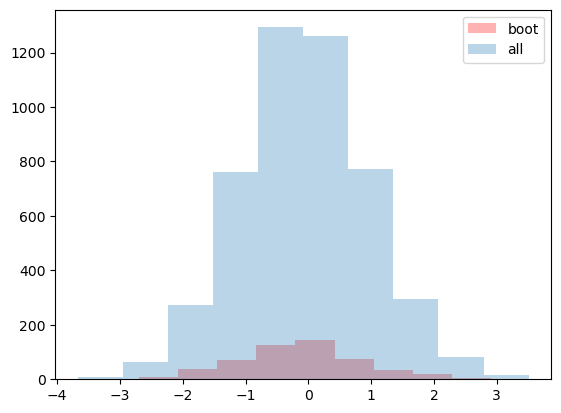

In [52]:
print(ds_Andes_SON['t2m'].min(), ds_Andes_SON['t2m'].max())

boot=bootstrap_chain(ds_Andes_SON, 60, 't2m')

print(np.shape(boot))
print(np.isnan(boot).sum())
print(np.nanmin(boot), np.nanmax(boot))

plt.hist(boot.flatten(), alpha=.3, label='boot', color='red')
plt.hist(ds_Andes_SON['t2m'].dropna(dim='sample'),alpha=.3, label='all')
plt.legend()

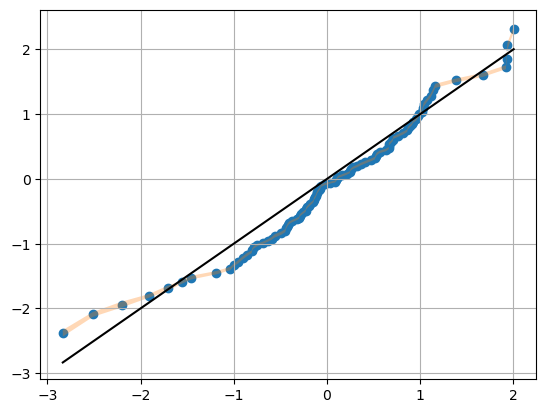

In [44]:
rng=np.random.default_rng(42)
q = np.linspace(0.01, 0.99, 99)

model = ds_Andes_SON['t2m'].dropna("sample").values

observed_q = np.nanquantile(era_SON_Andes_array['t_Andes'], q)
model_q = np.nanquantile(model, q)

boot_q = np.stack([
    np.nanquantile(
        rng.choice(model, size=len(model), replace=True),
        q
    )
    for _ in range(1000)
])

lower = np.percentile(boot_q, 2.5, axis=0)
upper = np.percentile(boot_q, 97.5, axis=0)
std=np.std(boot_q, axis=0)
mean = np.mean(boot_q, axis=0)

plt.plot(observed_q, observed_q, "k-")
plt.scatter(observed_q, model_q, label="Model")
plt.fill_between(
    observed_q,
    mean-std,
    mean+std,
    alpha=0.3
)
plt.grid()

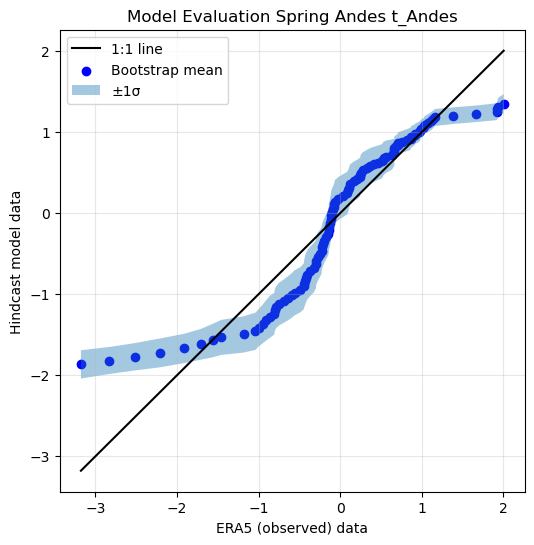

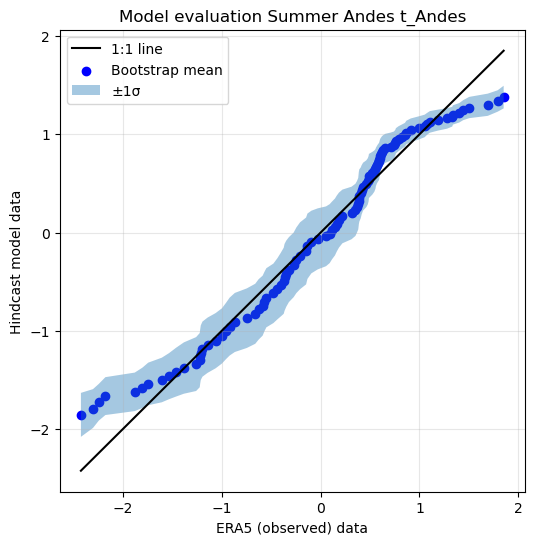

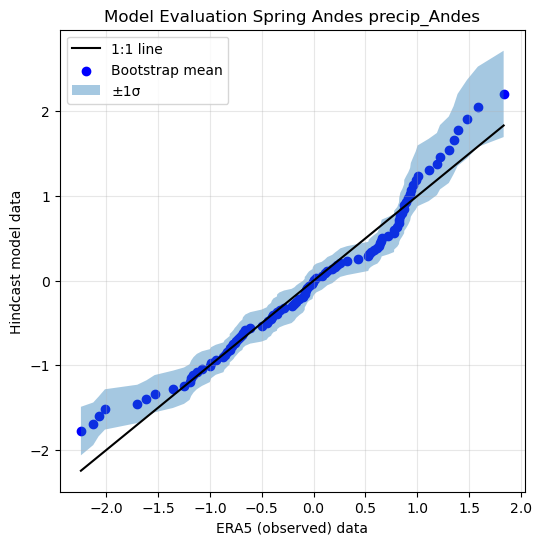

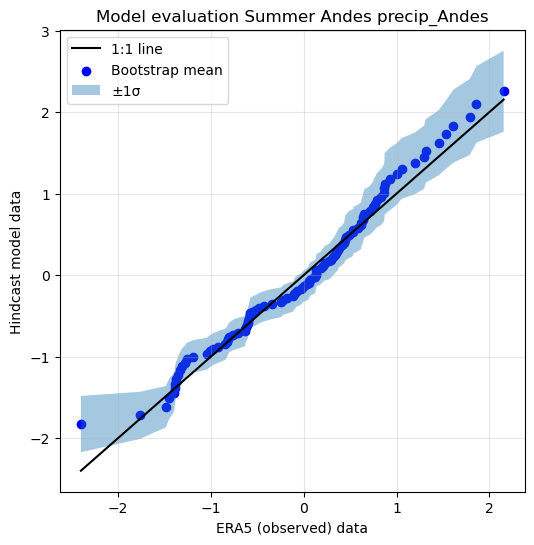

In [ ]:
folder='Model_eval_plots/'
mapping = {
    list(ds_Andes_DJF.data_vars)[0]: "t_Andes",
    list(ds_Andes_DJF.data_vars)[1]: "precip_Andes"  
}
for var, era_var in mapping.items():
    a=bootstrap_chain(ds_Andes_SON, 60, var=var)
    boot_perc_Andes_SON, era5_perc_Andes_SON, fig_Andes=model_eval_plot(a, era5_array=era_SON_Andes_array[era_var],
                                                input_title=f'Model Evaluation Spring Andes {era_var}')
    fig_Andes.savefig(folder+f'model_eval_Andes_spring_{era_var}.jpg', dpi=300)
    b=bootstrap_chain(ds_Andes_DJF, 60, var=var)
    boot_perc_Andes_DJF, era5_perc_Andes_DJF, fig_Andes_DJF=model_eval_plot(b,
                                                             era_DJF_Andes_array[era_var],
                                                             input_title=f'Model evaluation Summer Andes {era_var}')
    fig_Andes_DJF.savefig(folder+f'model_eval_Andes_summer_{era_var}.jpg', dpi=300)

Separate the different lead times from each other

In [ ]:
np.unique(ds_Andes_SON.init_month.values)

array([6, 7, 8, 9])

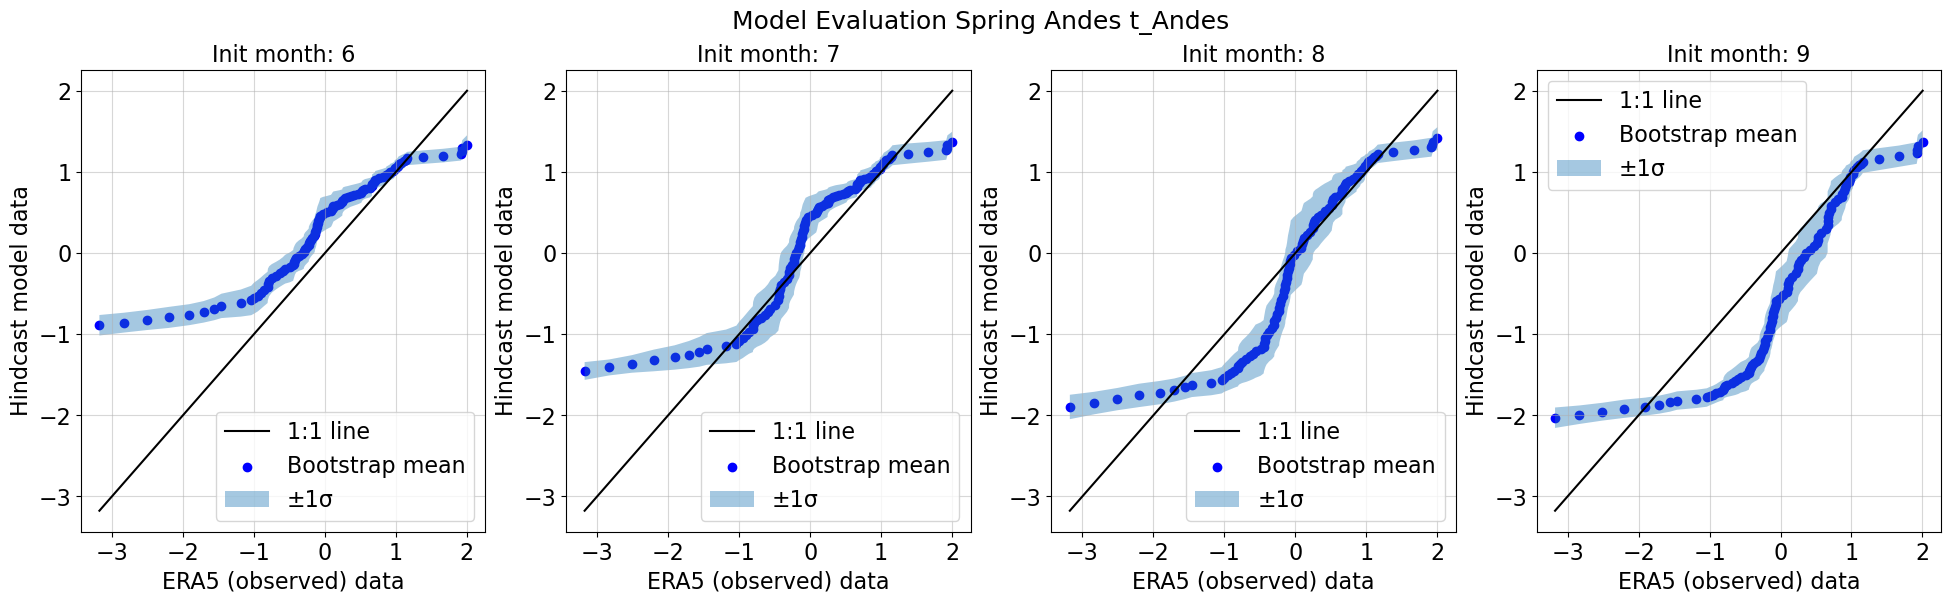

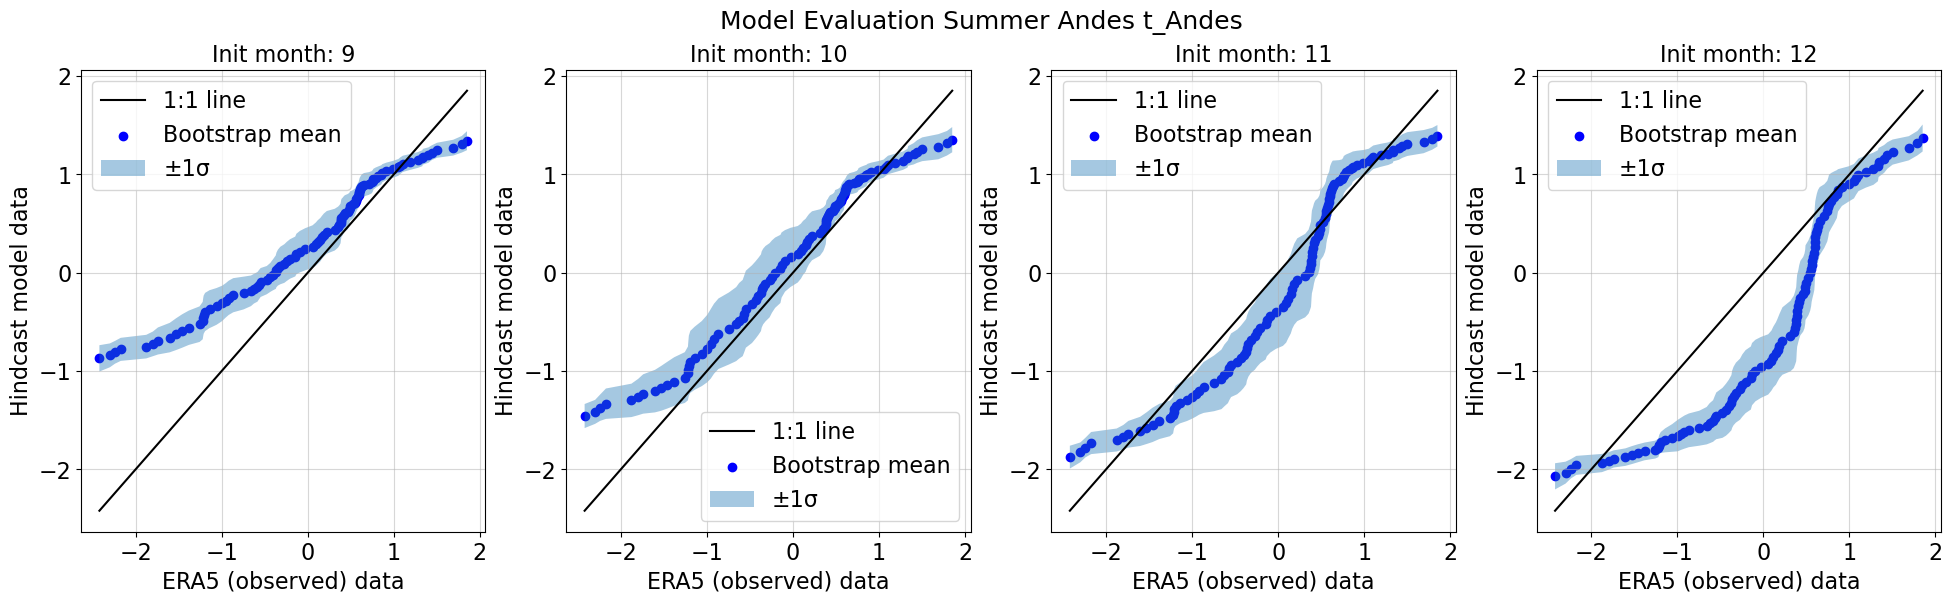

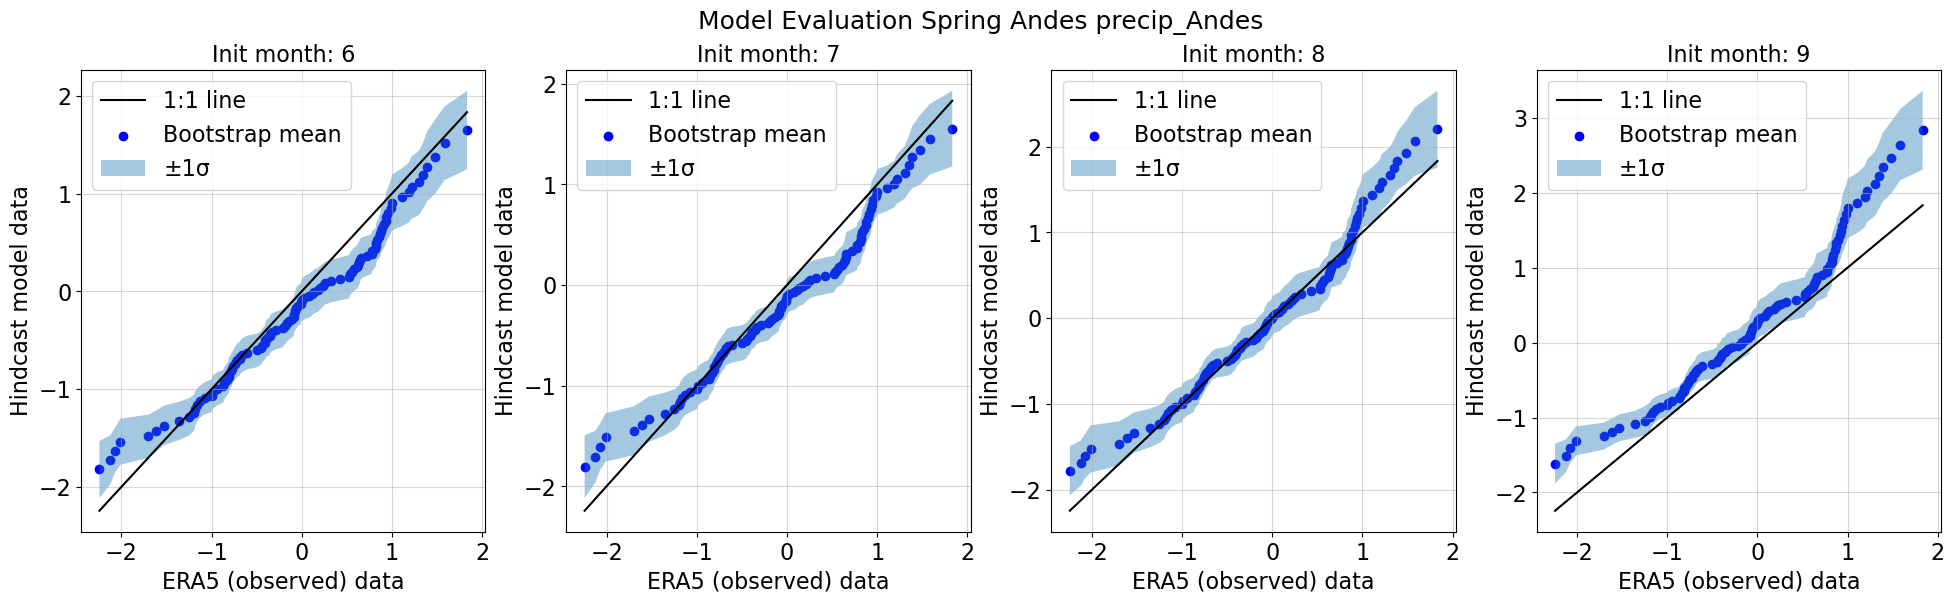

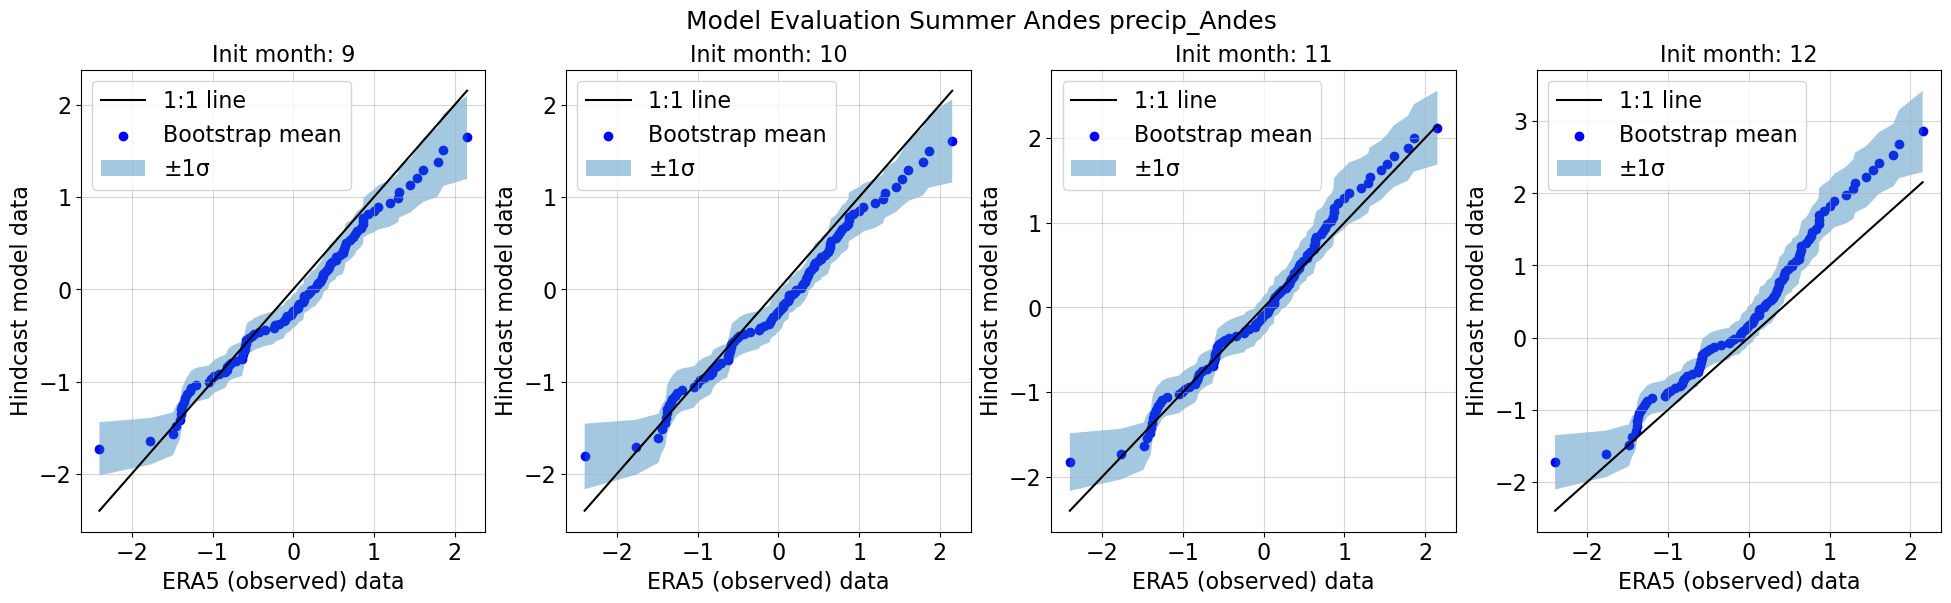

In [ ]:
mapping = {
    list(ds_Andes_DJF.data_vars)[0]: "t_Andes",
    list(ds_Andes_DJF.data_vars)[1]: "precip_Andes"  
}
months_list_SON=list(np.unique(ds_Andes_SON.init_month.values))
months_list_DJF=list(np.unique(ds_Andes_DJF.init_month.values))

for var, era_var in mapping.items():
    a=bootstrap_chain(ds_Andes_SON, 60, var=var, sep_lead=True)
    #print(np.shape(a))
    b=bootstrap_chain(ds_Andes_DJF, 60, var=var, sep_lead=True)
    boot_perc_Andes_SON, era5_perc_Andes_SON, fig_Andes=model_eval_plot(a, era5_array=era_SON_Andes_array[era_var],
                                                    input_title=f'Model Evaluation Spring Andes {era_var}',
                                                    ds_init=ds_Andes_SON[var])
    boot_perc_Andes_DJF, era5_perc_Andes_DJF, fig_Andes_DJF=model_eval_plot(b, era5_array=era_DJF_Andes_array[era_var],
                                                        input_title=f'Model Evaluation Summer Andes {era_var}',
                                                        ds_init=ds_Andes_DJF[var])
    fig_Andes.savefig(folder+f'model_eval_Andes_spring_{era_var}_all_init.jpg', dpi=300)
    fig_Andes_DJF.savefig(folder+f'model_eval_Andes_summer_{era_var}_all_init.jpg', dpi=300)

    

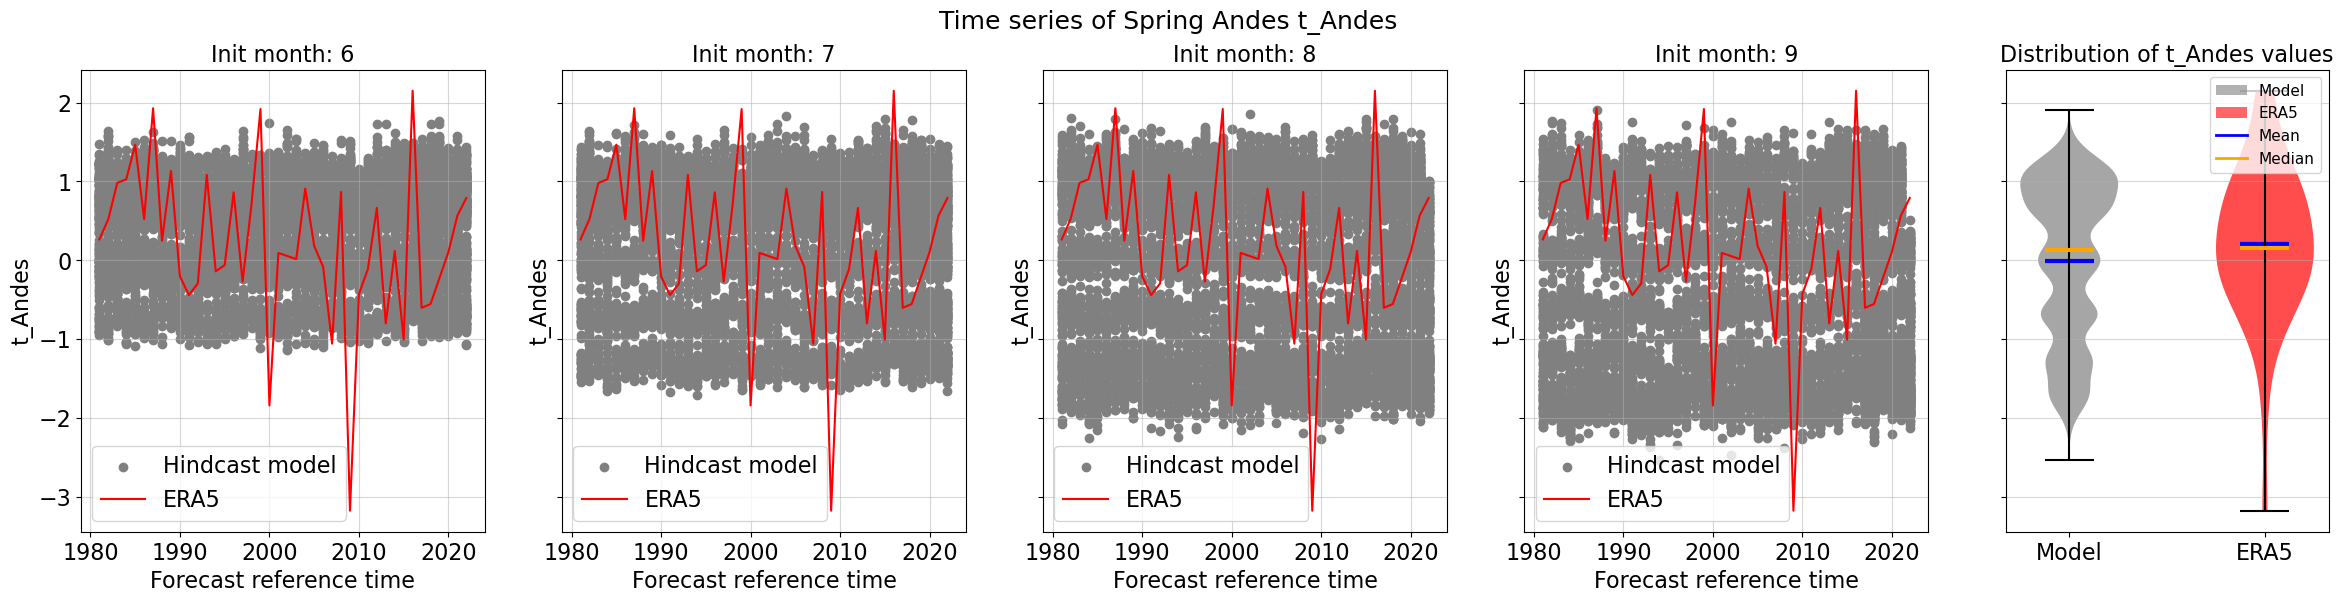

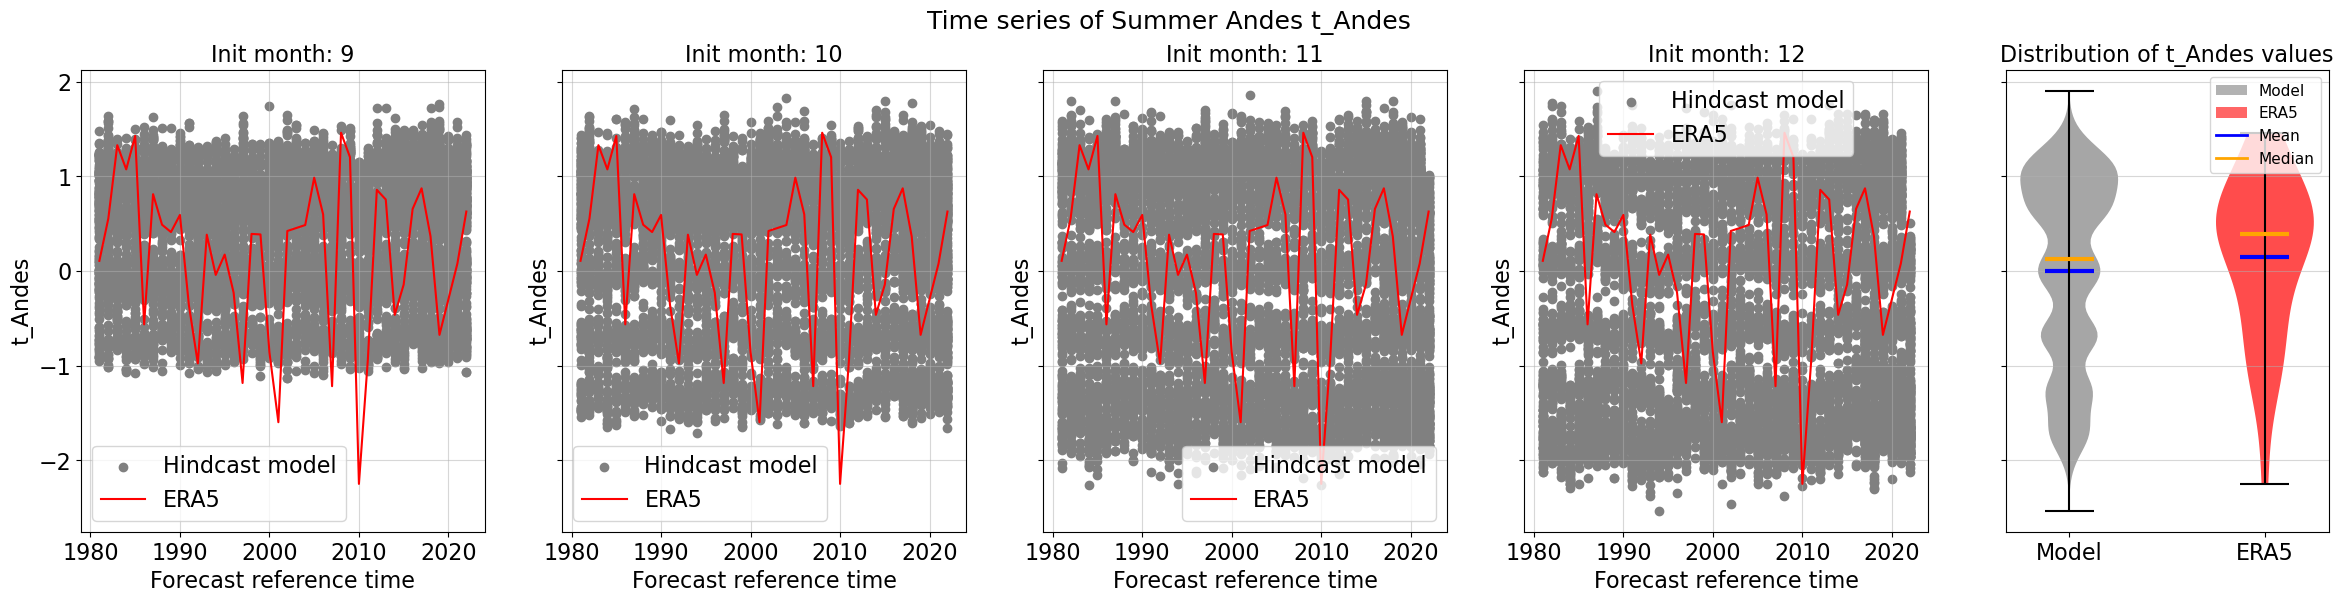

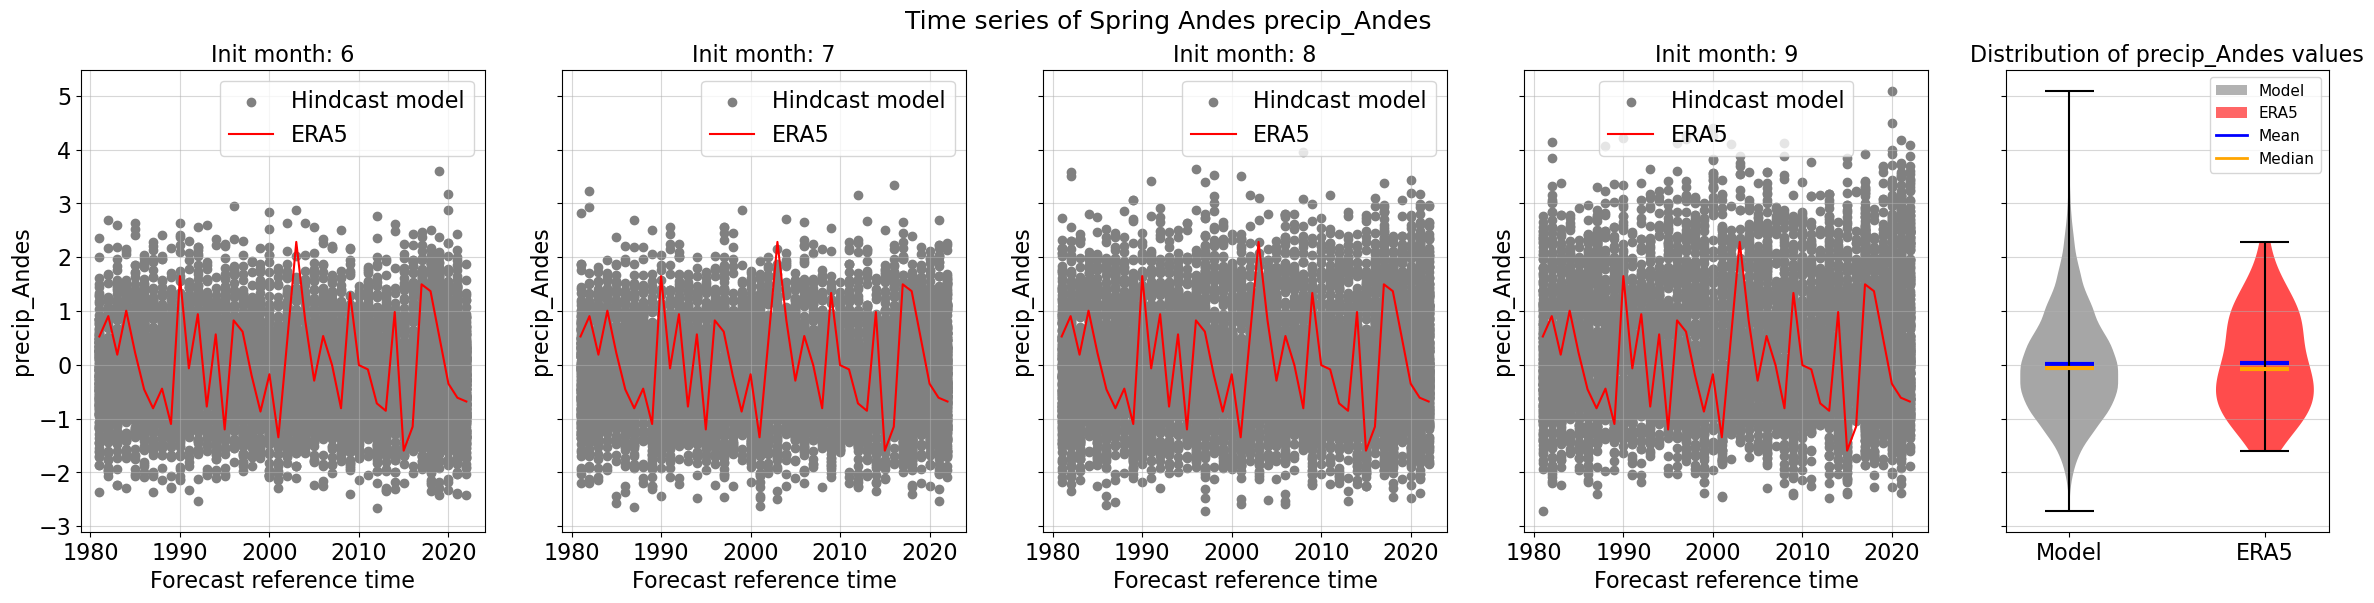

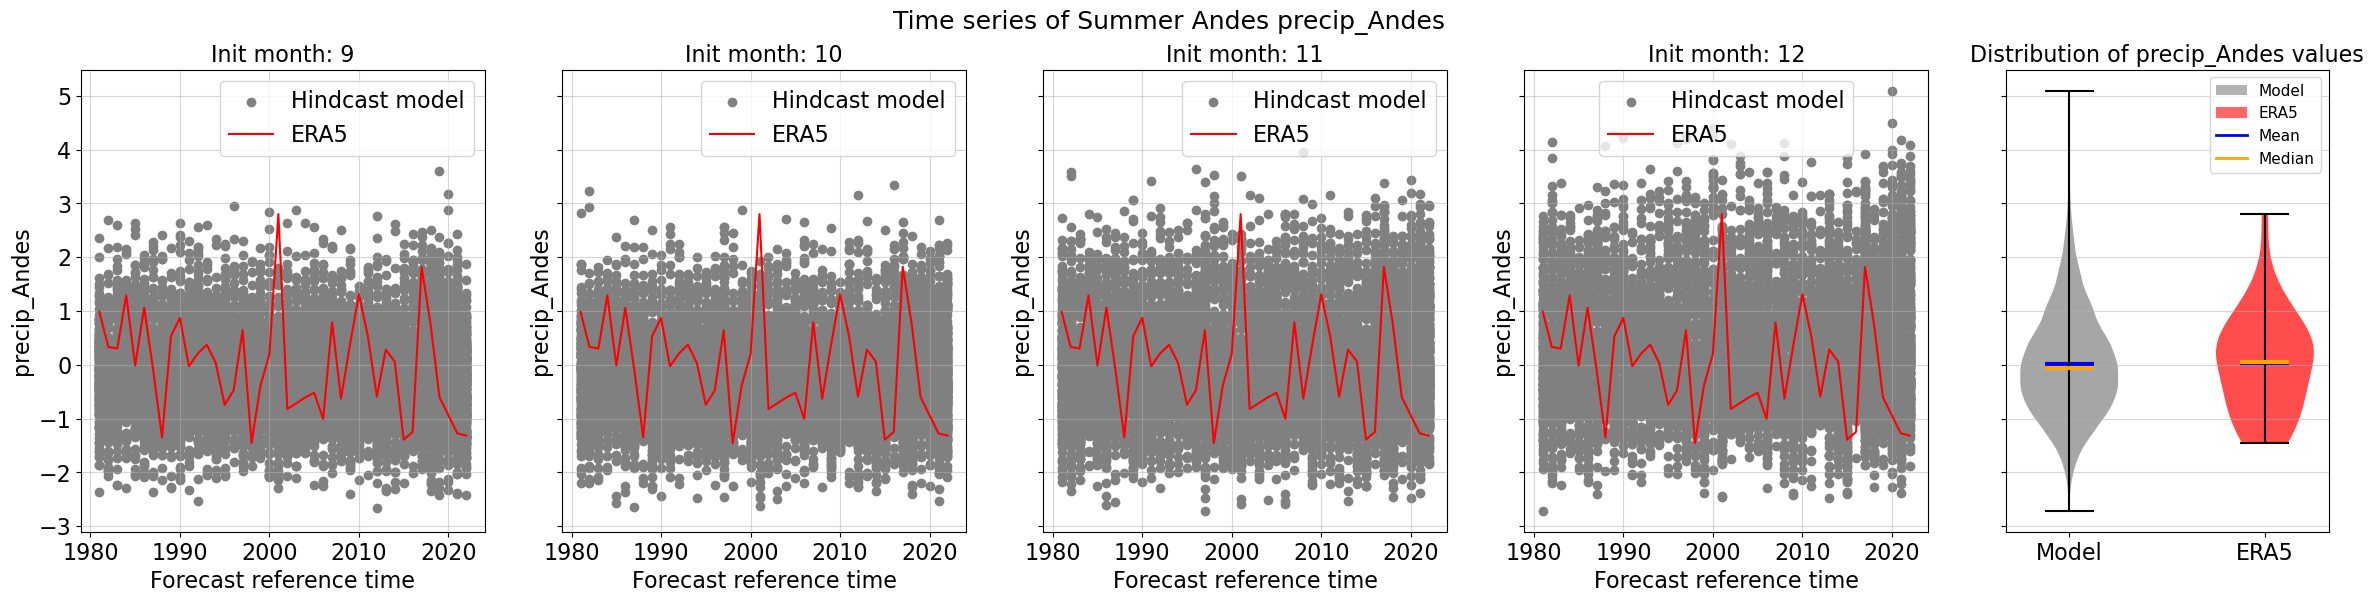

In [ ]:
##timeseries of andes t2m and precip for all init months
for var, era_var in mapping.items():
    fig_ts_Andes_SON=time_series_plot(ds_Andes_SON[var], era_var=era_var, era5_array=era_SON_Andes_array,
                                      input_title=f'Time series of Spring Andes {era_var}')
    fig_ts_Andes_SON.savefig(folder+f'model_ts_Andes_spring_{era_var}.jpg', dpi=300)

    fig_ts_Andes_DJF=time_series_plot(ds_Andes_DJF[var], era_var=era_var, era5_array=era_DJF_Andes_array,
                                          input_title=f'Time series of Summer Andes {era_var}')
    fig_ts_Andes_DJF.savefig(folder+f'model_ts_Andes_summer_{era_var}.jpg', dpi=300)

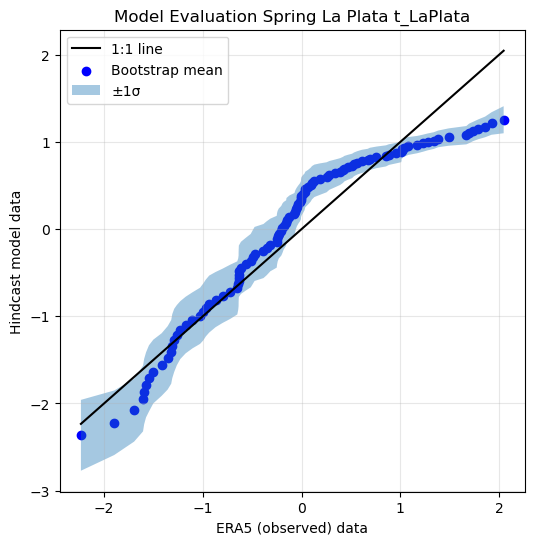

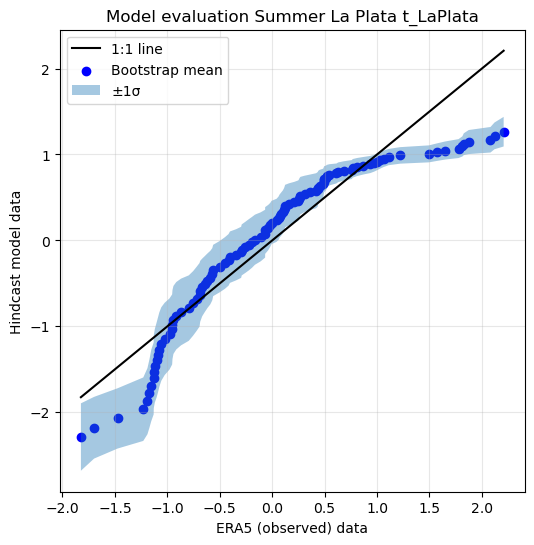

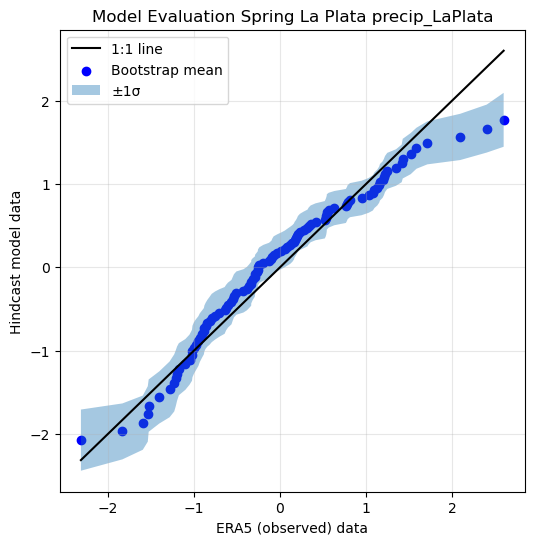

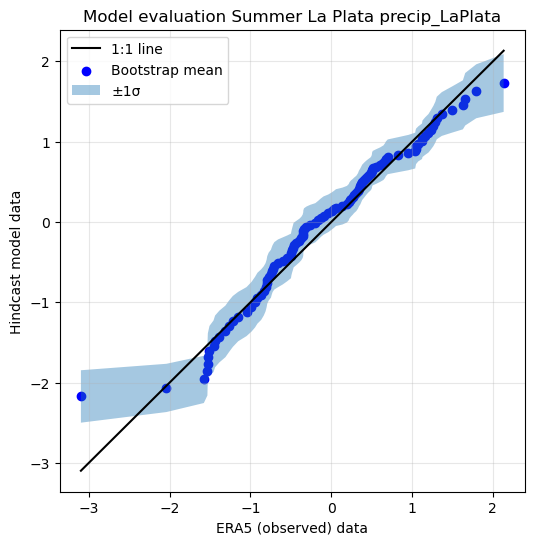

In [ ]:
ds_LP_SON = ds_LP_SON.set_index(
    sample=["forecast_reference_time", "number", "init_month"]
)

ds_LP_DJF = ds_LP_DJF.set_index(
    sample=["forecast_reference_time", "number", "init_month"]
)
folder='Model_eval_plots/'
mapping2 = {
    list(ds_LP_DJF.data_vars)[0]: "t_LaPlata",
    list(ds_LP_DJF.data_vars)[1]: "precip_LaPlata"  
}
for var, era_var in mapping2.items():
    a=bootstrap_chain(ds_LP_SON, 60, var=var)
    boot_perc_LP_SON, era5_perc_LP_SON, fig_LP=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                input_title=f'Model Evaluation Spring La Plata {era_var}')
    fig_LP.savefig(folder+f'model_eval_LP_spring_{era_var}.jpg', dpi=300)
    b=bootstrap_chain(ds_LP_DJF, 60, var=var)
    boot_perc_LP_DJF, era5_perc_LP_DJF, fig_LP_DJF=model_eval_plot(b,
                                                             era_DJF_LaPlata_array[era_var],
                                                             input_title=f'Model evaluation Summer La Plata {era_var}')
    fig_LP_DJF.savefig(folder+f'model_eval_LP_summer_{era_var}.jpg', dpi=300)

(60, 4, 60)


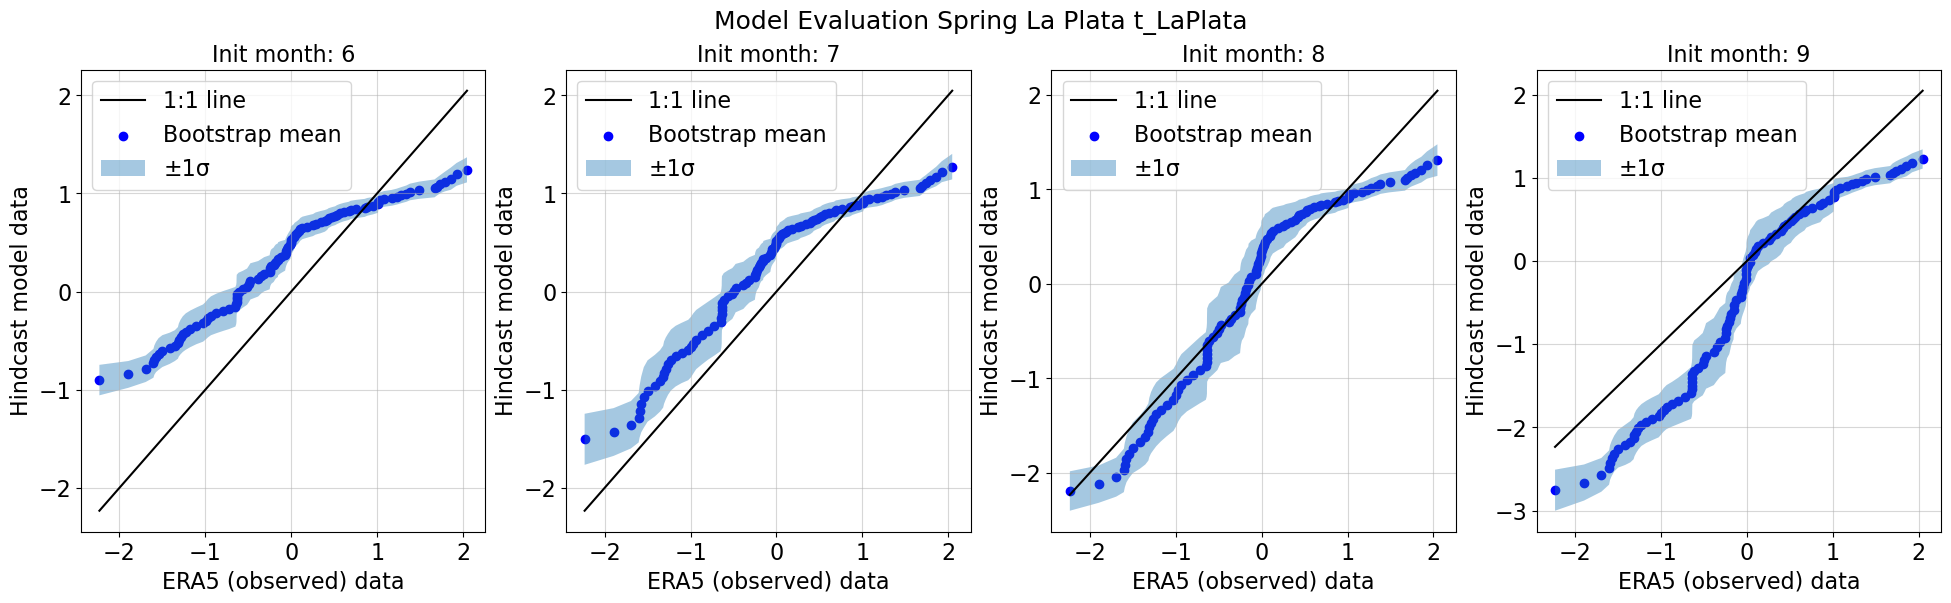

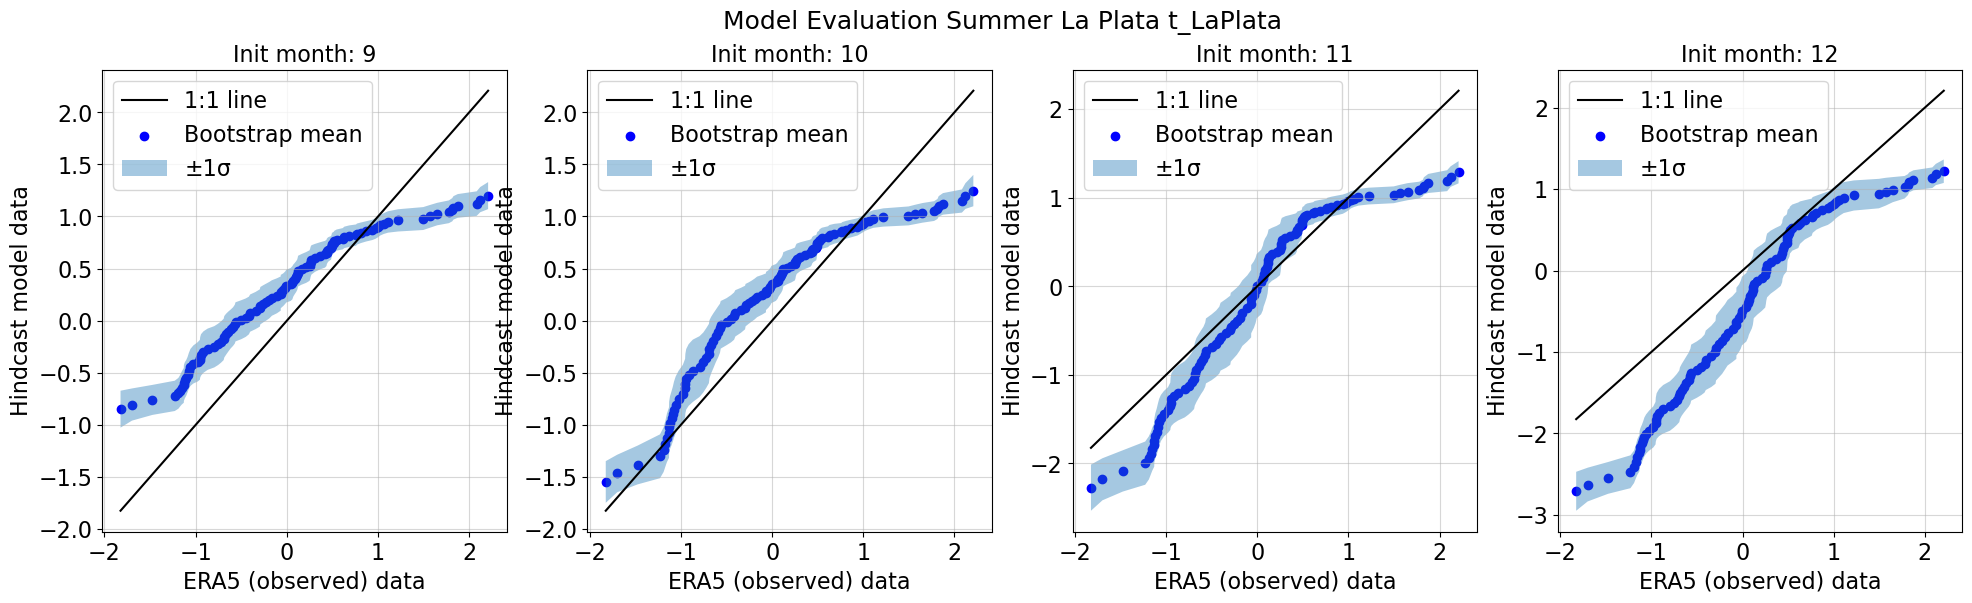

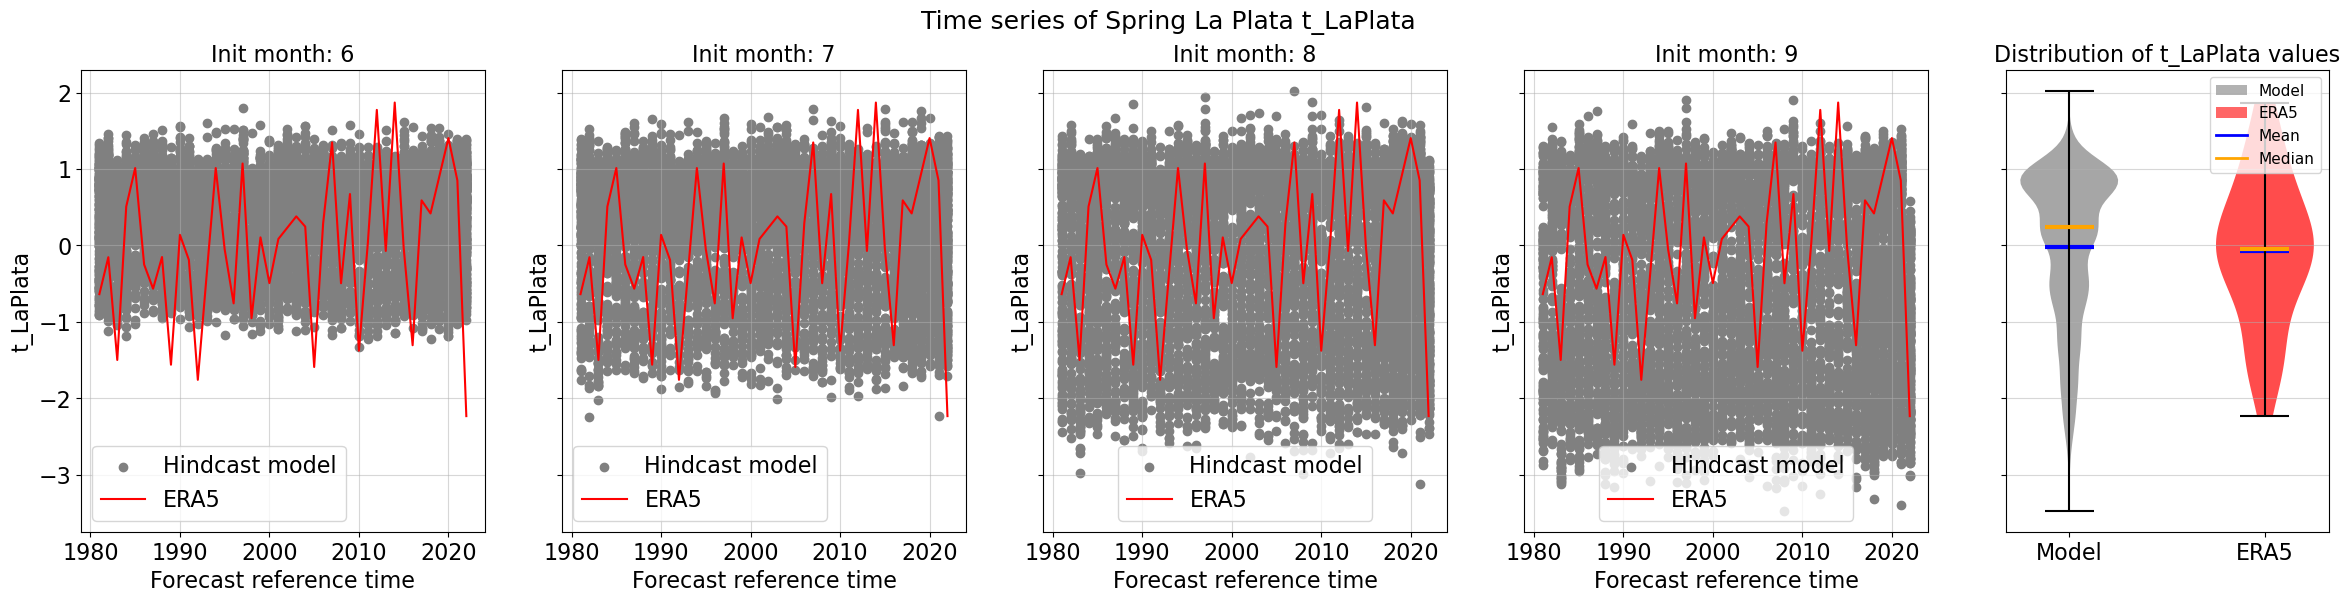

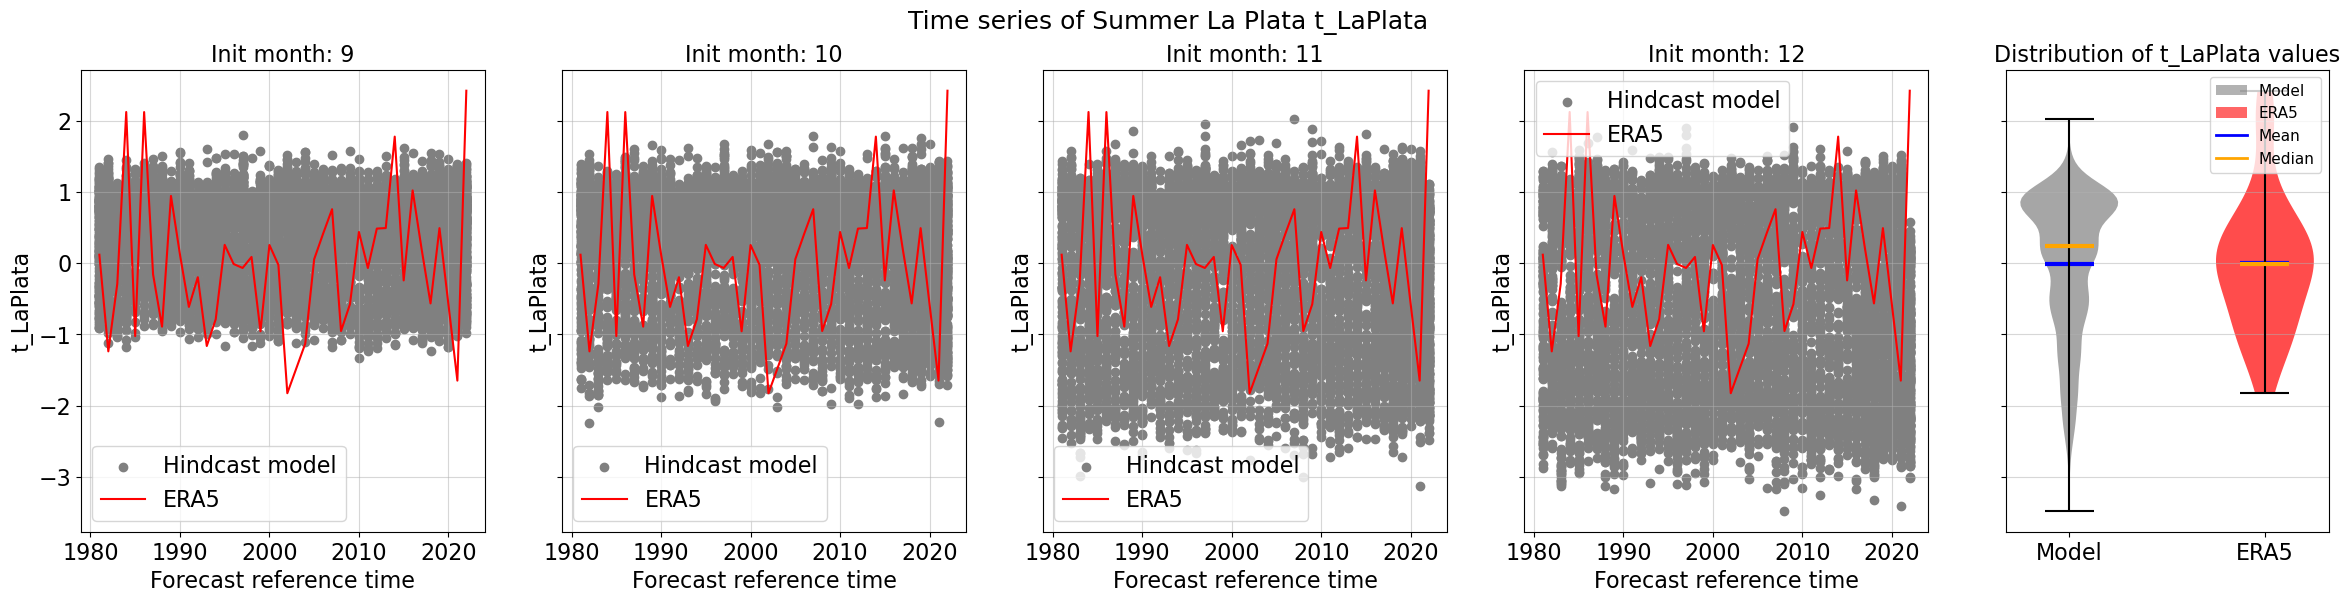

(60, 4, 60)


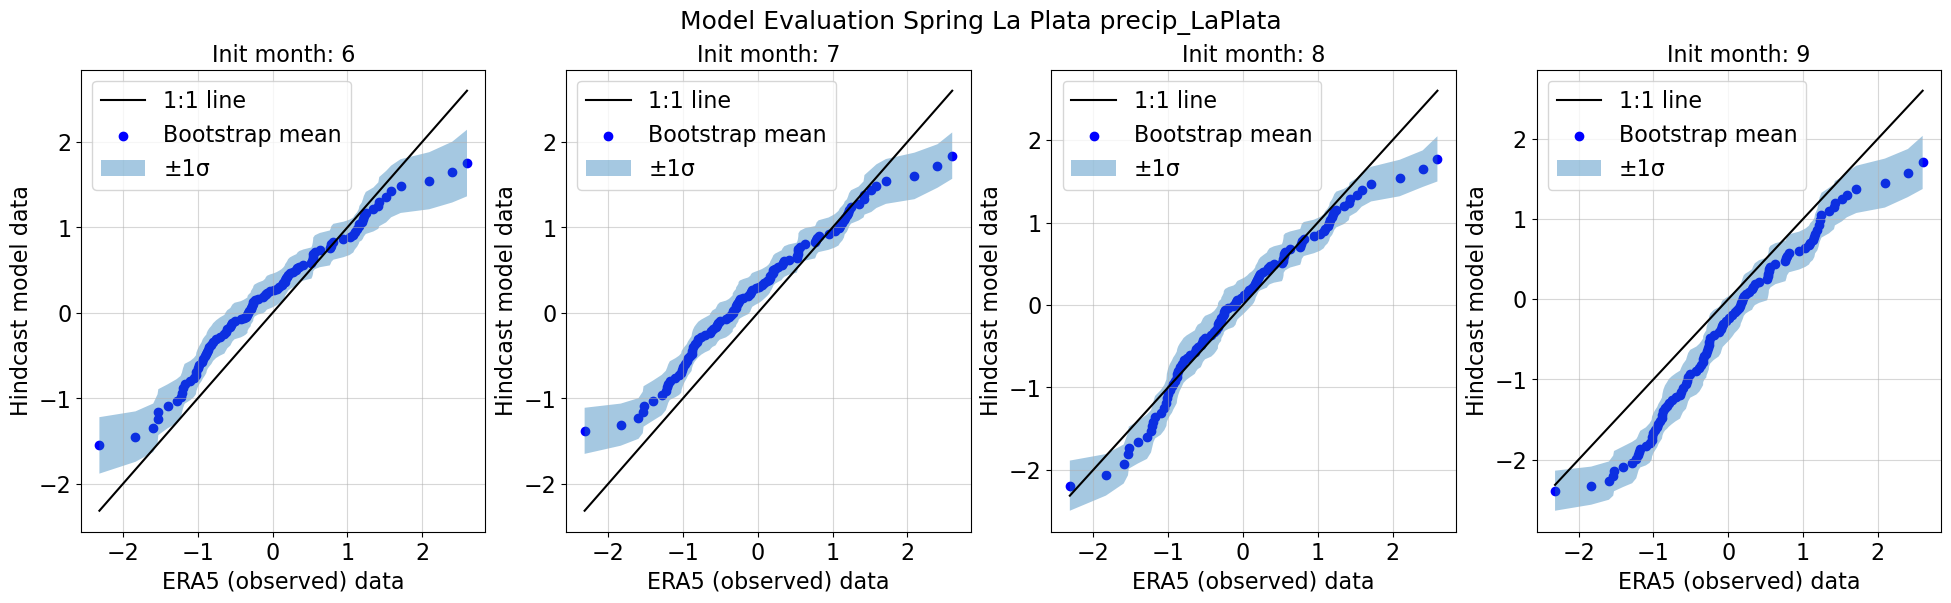

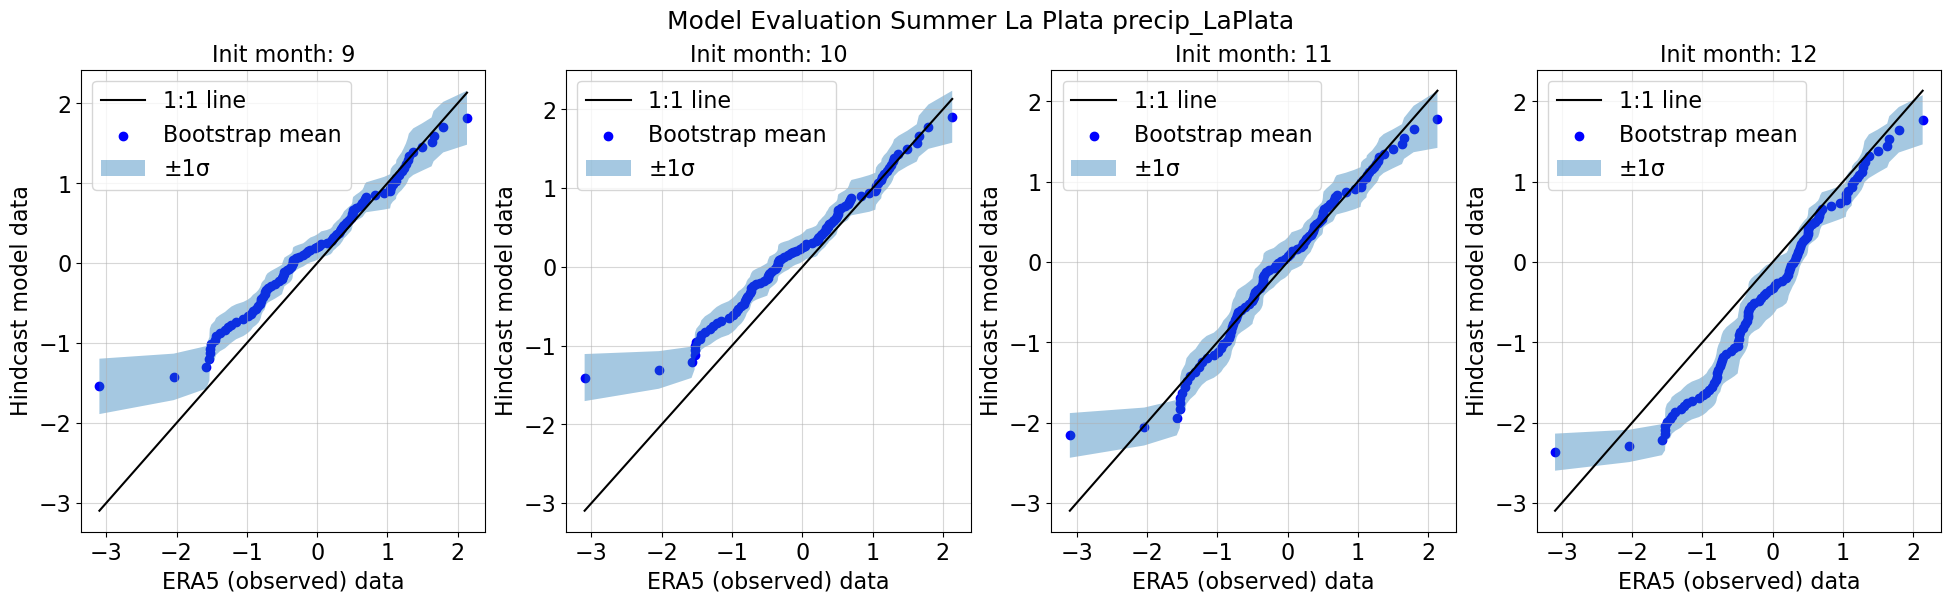

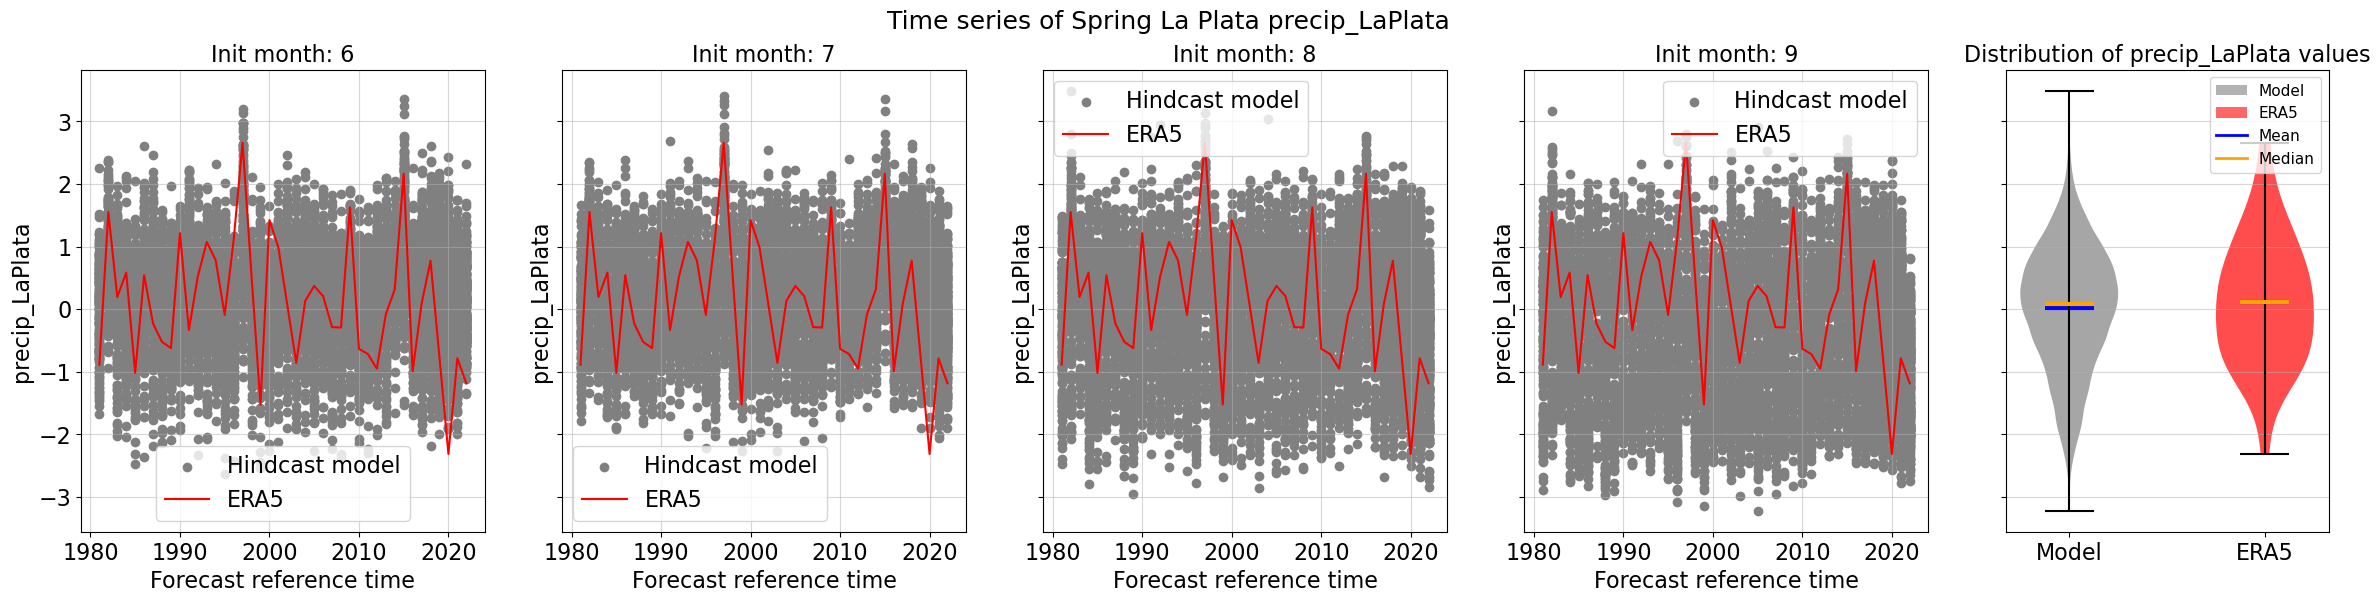

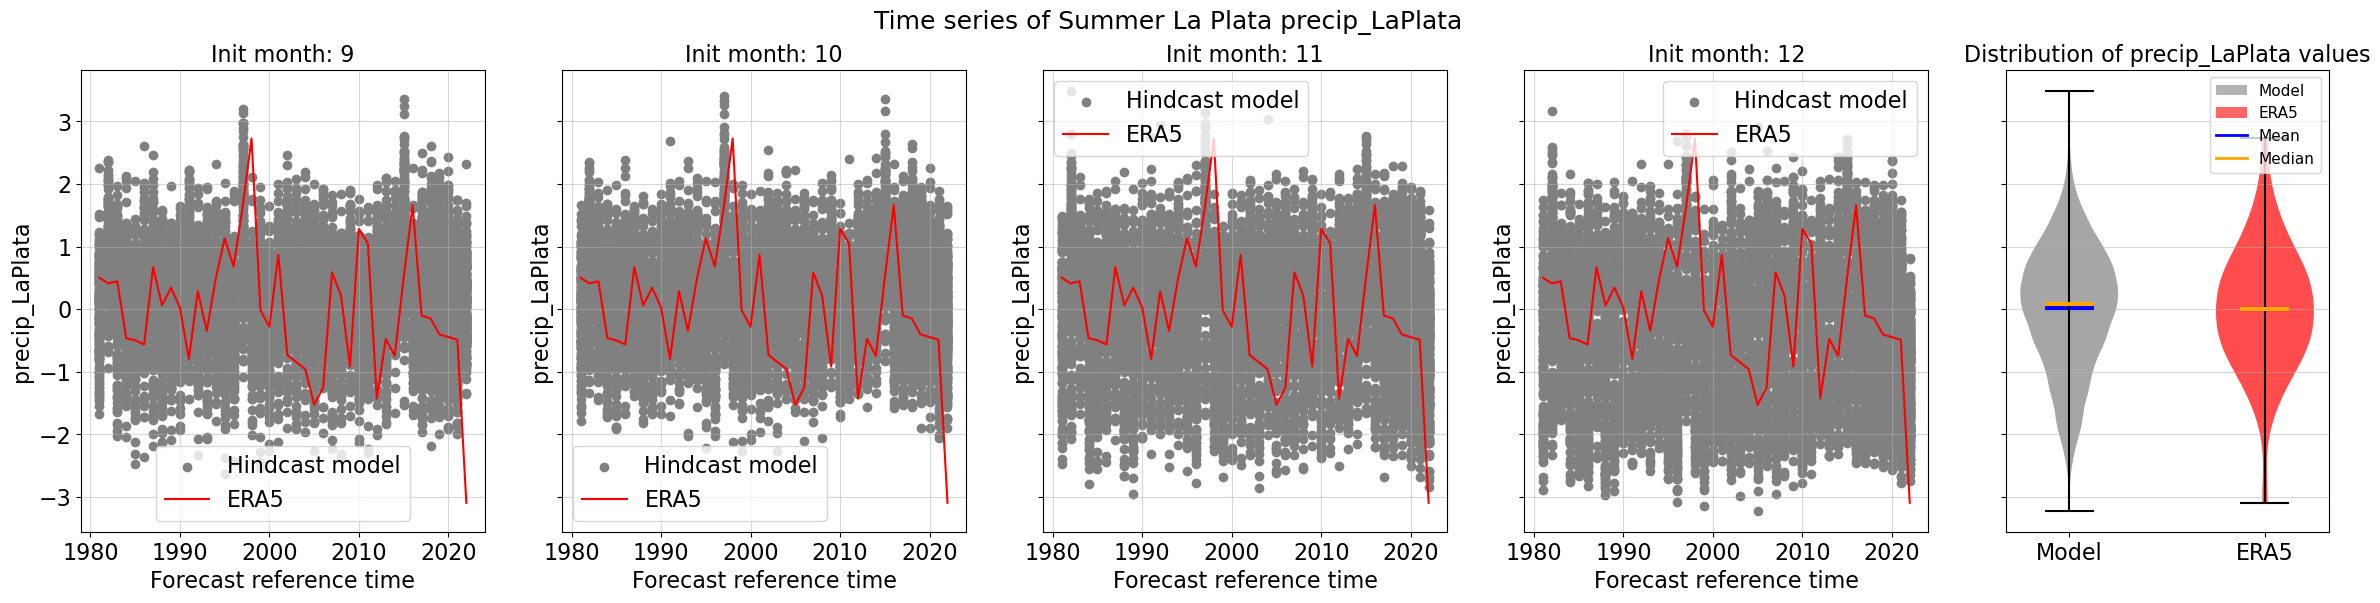

In [ ]:

folder='Model_eval_plots/'
mapping = {
    list(ds_LP_DJF.data_vars)[0]: "t_LaPlata",
    list(ds_LP_DJF.data_vars)[1]: "precip_LaPlata"  
}
months_list_SON=list(np.unique(ds_LP_SON.init_month.values))
months_list_DJF=list(np.unique(ds_LP_DJF.init_month.values))

for var, era_var in mapping.items():
    a=bootstrap_chain(ds_LP_SON, 60, var=var, sep_lead=True)
    print(np.shape(a))
    b=bootstrap_chain(ds_LP_DJF, 60, var=var, sep_lead=True)

    boot_perc_LP_SON, era5_perc_LP_SON, fig_LP=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                        input_title=f'Model Evaluation Spring La Plata {era_var}',
                                                        ds_init=ds_LP_SON[var])
    boot_perc_LP_DJF, era5_perc_LP_DJF, fig_LP_DJF=model_eval_plot(b, era5_array=era_DJF_LaPlata_array[era_var],
                                                            input_title=f'Model Evaluation Summer La Plata {era_var}',
                                                            ds_init=ds_LP_DJF[var])
    
    fig_LP.savefig(folder+f'model_eval_LaPlata_spring_{era_var}_all_init.jpg', dpi=300)
    fig_LP_DJF.savefig(folder+f'model_eval_LaPlata_summer_{era_var}_all_init.jpg', dpi=300)

    ##timeseries of LP Spring t2m and precip for all init months
    fig_ts_LP_SON=time_series_plot(ds_LP_SON[var], era_var=era_var, era5_array=era_SON_LaPlata_array,
                                      input_title=f'Time series of Spring La Plata {era_var}')
    fig_ts_LP_SON.savefig(folder+f'model_ts_LP_spring_{era_var}.jpg', dpi=300)

    ##timeseries of LP summer t2m and precip for all init months
    fig_ts_LP_DJF=time_series_plot(ds_LP_DJF[var], era_var=era_var, era5_array=era_DJF_LaPlata_array,
                                          input_title=f'Time series of Summer La Plata {era_var}')
    fig_ts_LP_DJF.savefig(folder+f'model_ts_LP_summer_{era_var}.jpg', dpi=300)
        

# Evaluate computed indices

In [7]:
#load indices data
ds_ocean_SON=xr.open_dataset(path+'ENSO_IOD_SON.nc')
ds_ocean_DJF=xr.open_dataset(path+'ENSO_IOB_DJF.nc')

ds_ocean_SON=drop_duplicates(ds_ocean_SON)
ds_ocean_DJF=drop_duplicates(ds_ocean_DJF)



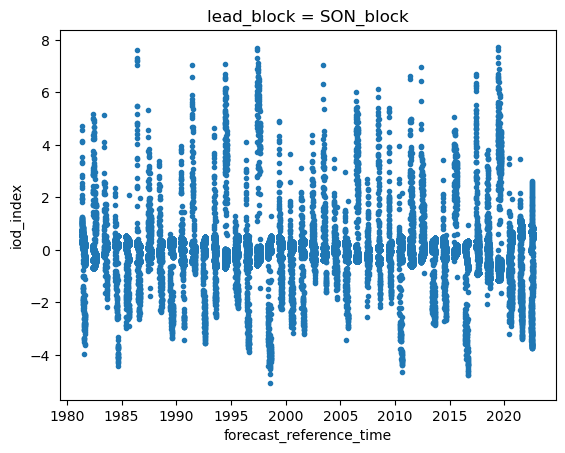

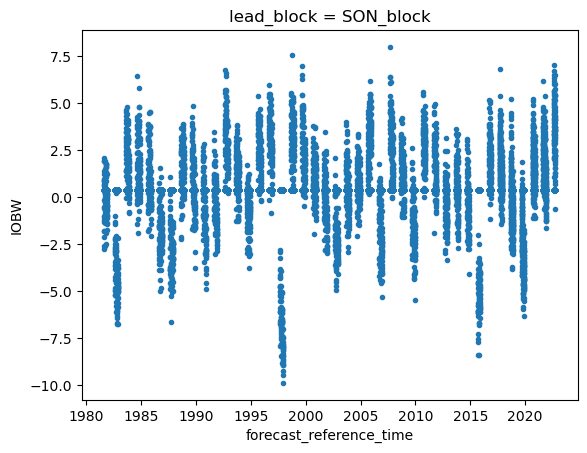

In [32]:
ds_ocean_SON['iod_index'].plot(x='forecast_reference_time', marker='.', linestyle='none')
list(ds_ocean_SON.data_vars)[0]
plt.show()
ds_ocean_DJF['IOBW'].plot(x='forecast_reference_time', marker='.', linestyle='none')

In [33]:
for init in [6,7,8,9]:
    print('SON: ', ds_ocean_SON.sel(init_month=init)['iod_index'].max(),
    ds_ocean_SON['iod_index'].sel(init_month=init).min())

for init in [9,10,11,12]:
    print('DJF:', ds_ocean_DJF.sel(init_month=init)['IOBW'].max(), 
          ds_ocean_DJF.sel(init_month=init)['IOBW'].min())

SON:  <xarray.DataArray 'iod_index' ()> Size: 8B
array(7.73338187)
Coordinates:
    lead_block  <U9 36B ...
    init_month  int64 8B 6 <xarray.DataArray 'iod_index' ()> Size: 8B
array(-4.40601877)
Coordinates:
    lead_block  <U9 36B ...
    init_month  int64 8B 6
SON:  <xarray.DataArray 'iod_index' ()> Size: 8B
array(7.13007019)
Coordinates:
    lead_block  <U9 36B ...
    init_month  int64 8B 7 <xarray.DataArray 'iod_index' ()> Size: 8B
array(-4.32719989)
Coordinates:
    lead_block  <U9 36B ...
    init_month  int64 8B 7
SON:  <xarray.DataArray 'iod_index' ()> Size: 8B
array(6.52313779)
Coordinates:
    lead_block  <U9 36B ...
    init_month  int64 8B 8 <xarray.DataArray 'iod_index' ()> Size: 8B
array(-5.06378574)
Coordinates:
    lead_block  <U9 36B ...
    init_month  int64 8B 8
SON:  <xarray.DataArray 'iod_index' ()> Size: 8B
array(5.30394623)
Coordinates:
    lead_block  <U9 36B ...
    init_month  int64 8B 9 <xarray.DataArray 'iod_index' ()> Size: 8B
array(-4.76242256)
Coordina

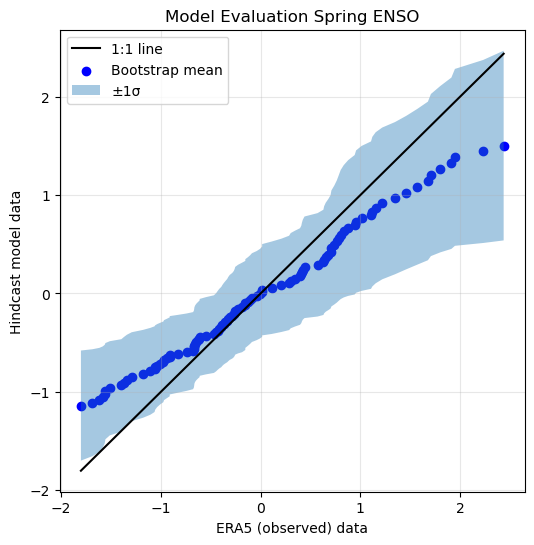

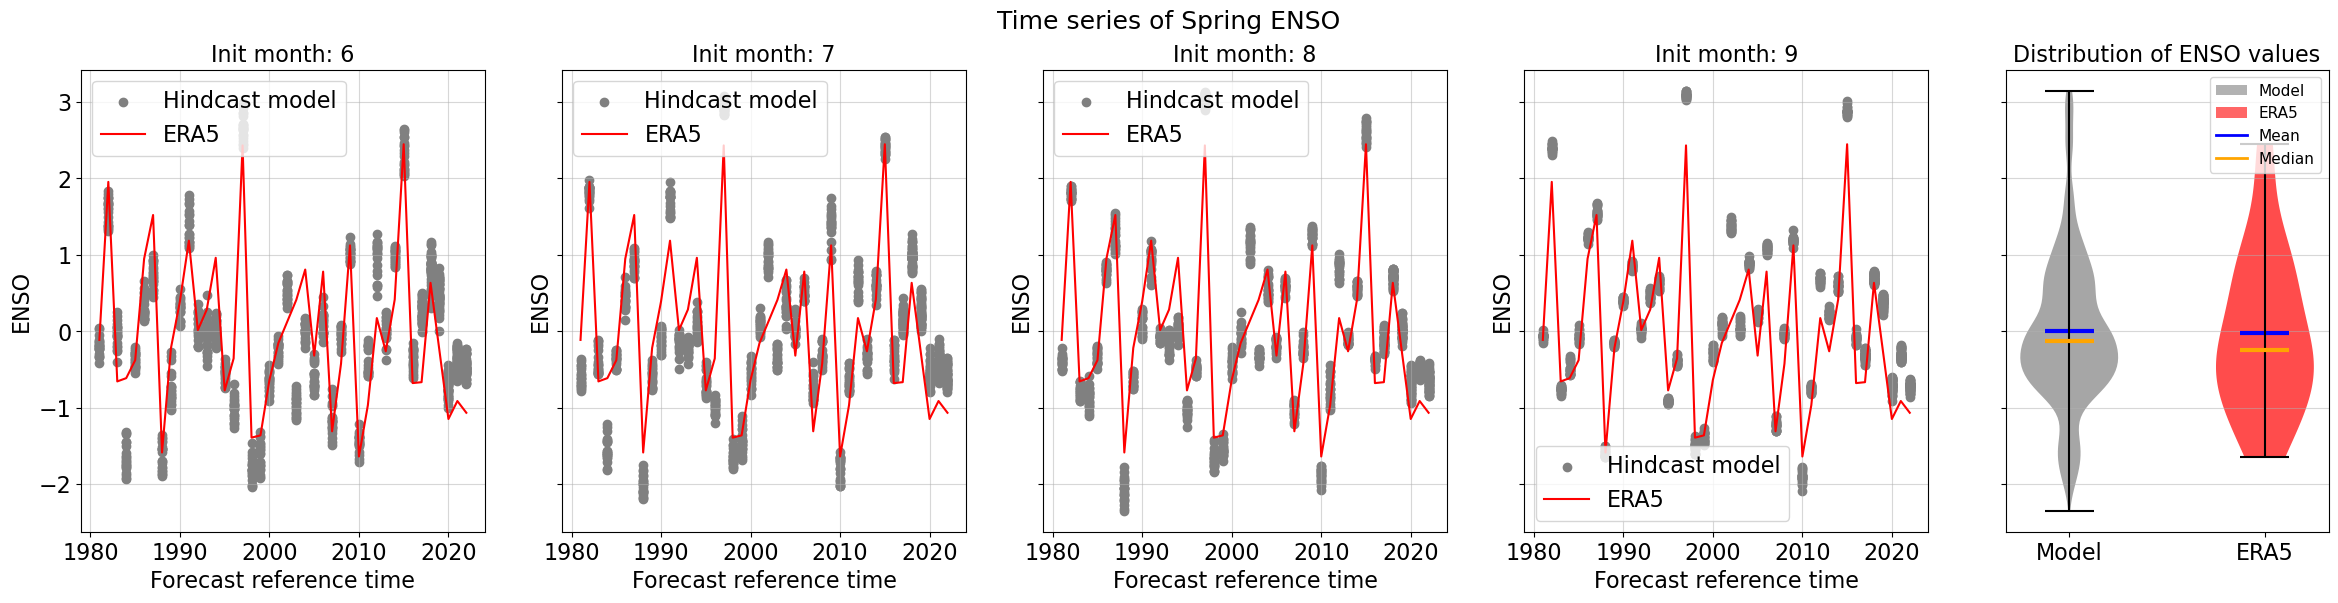

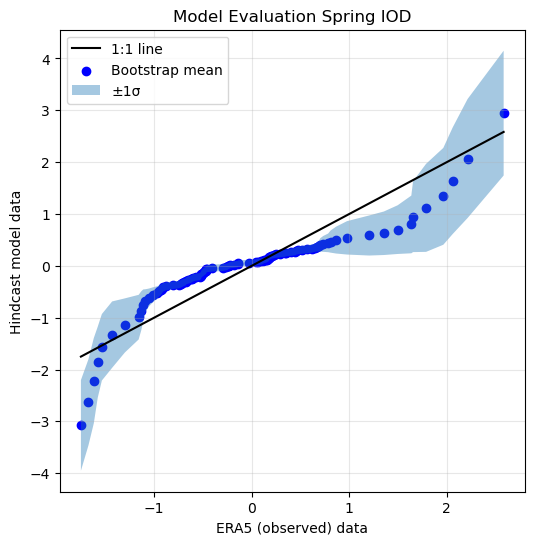

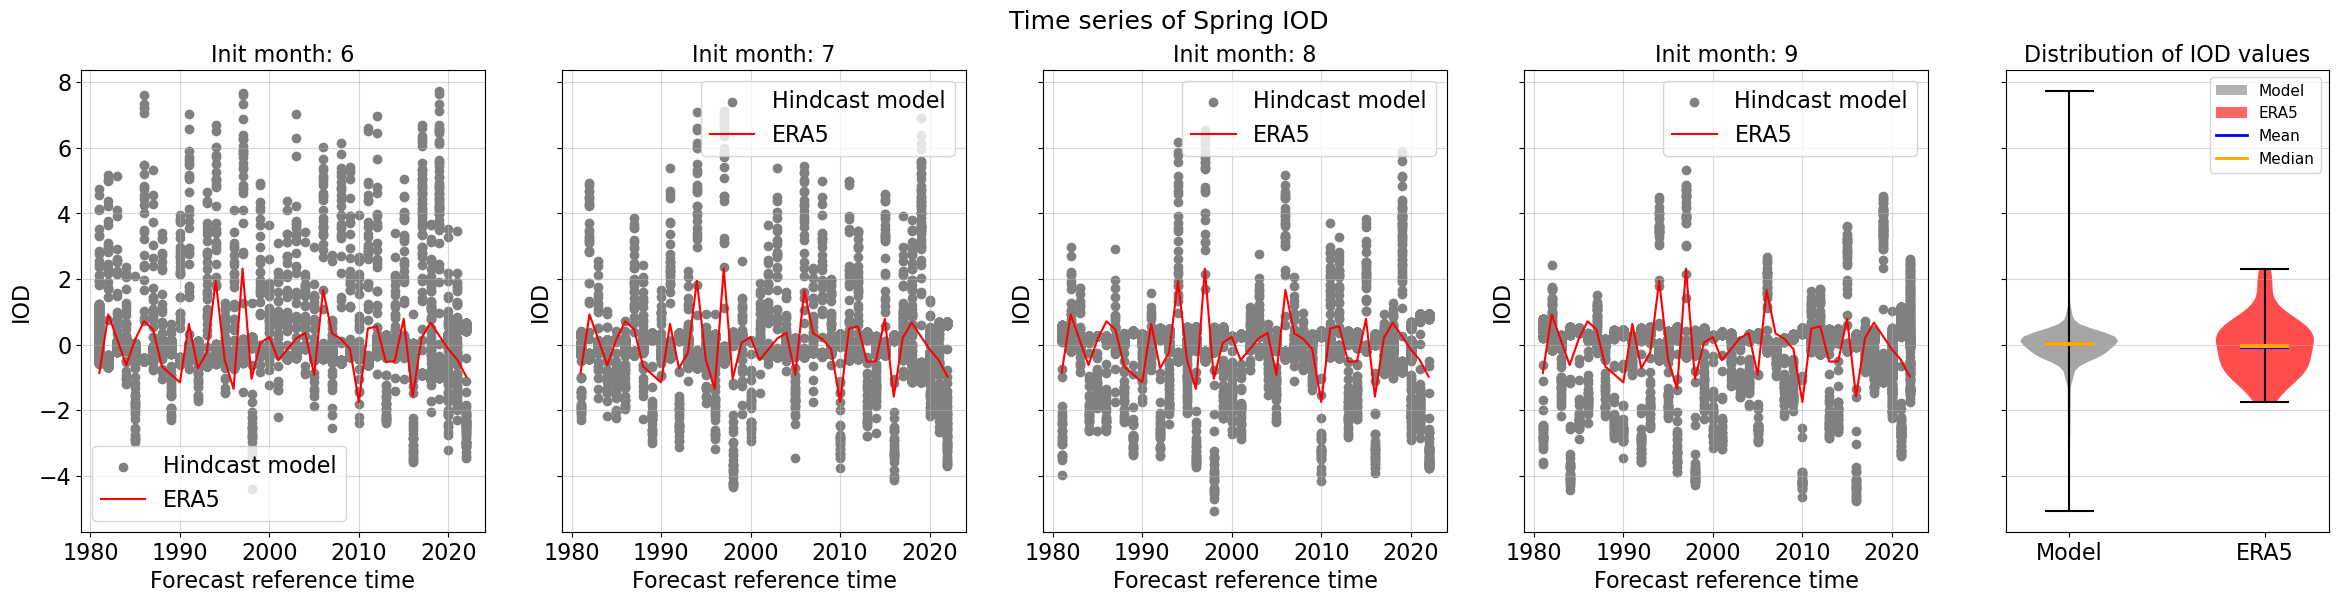

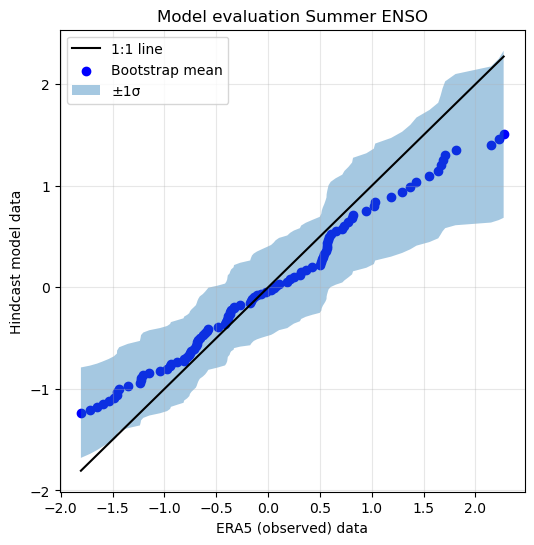

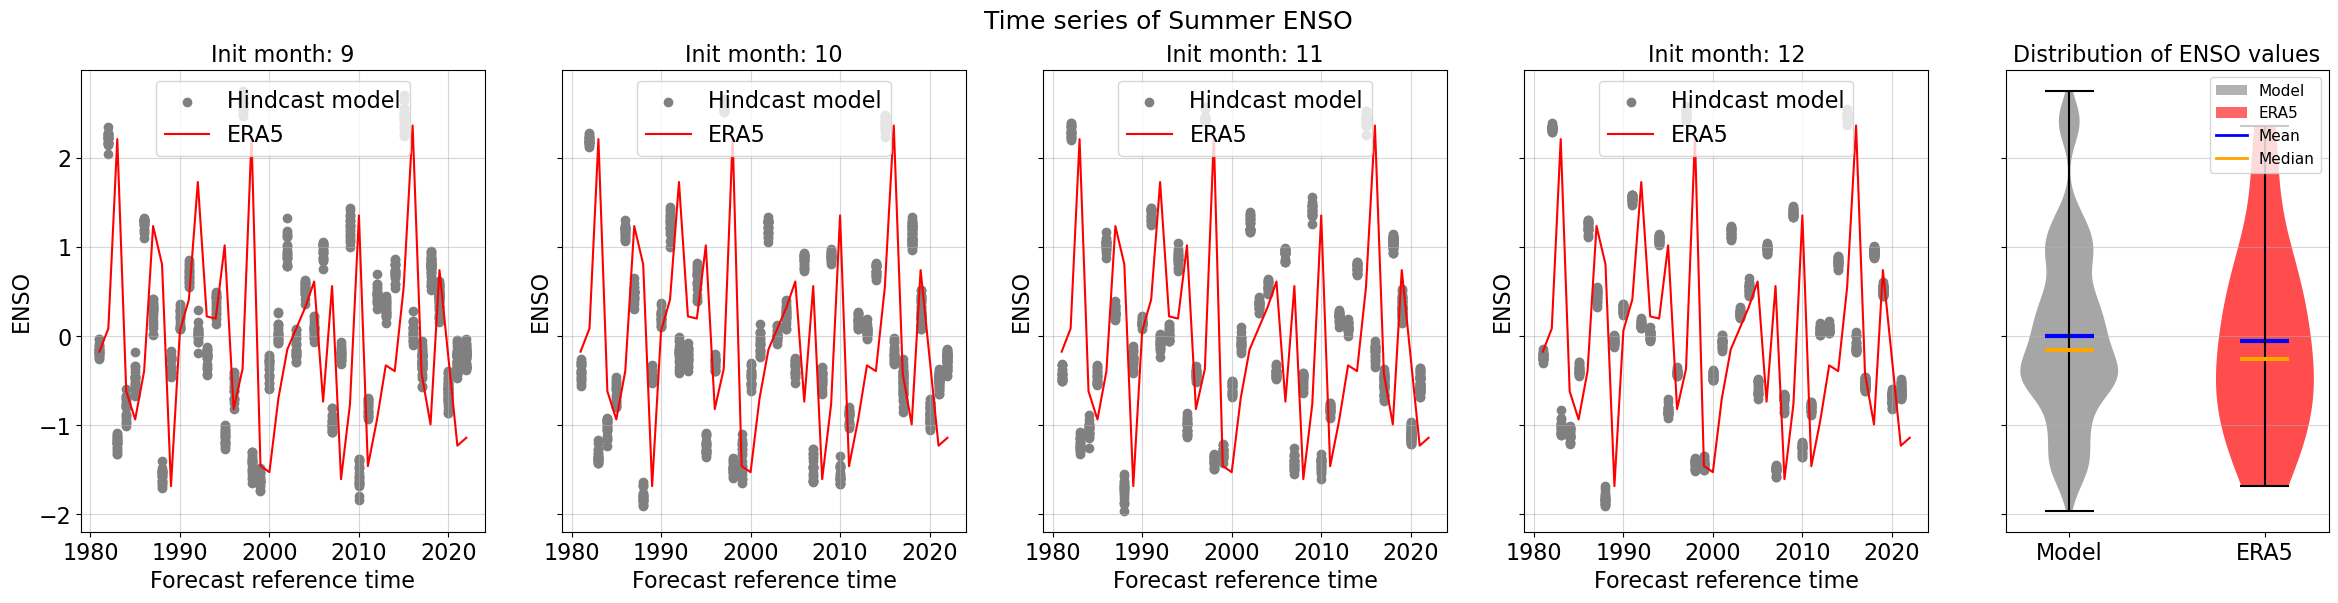

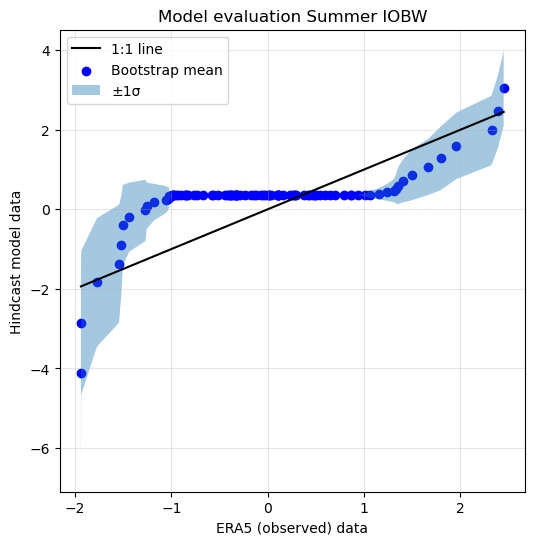

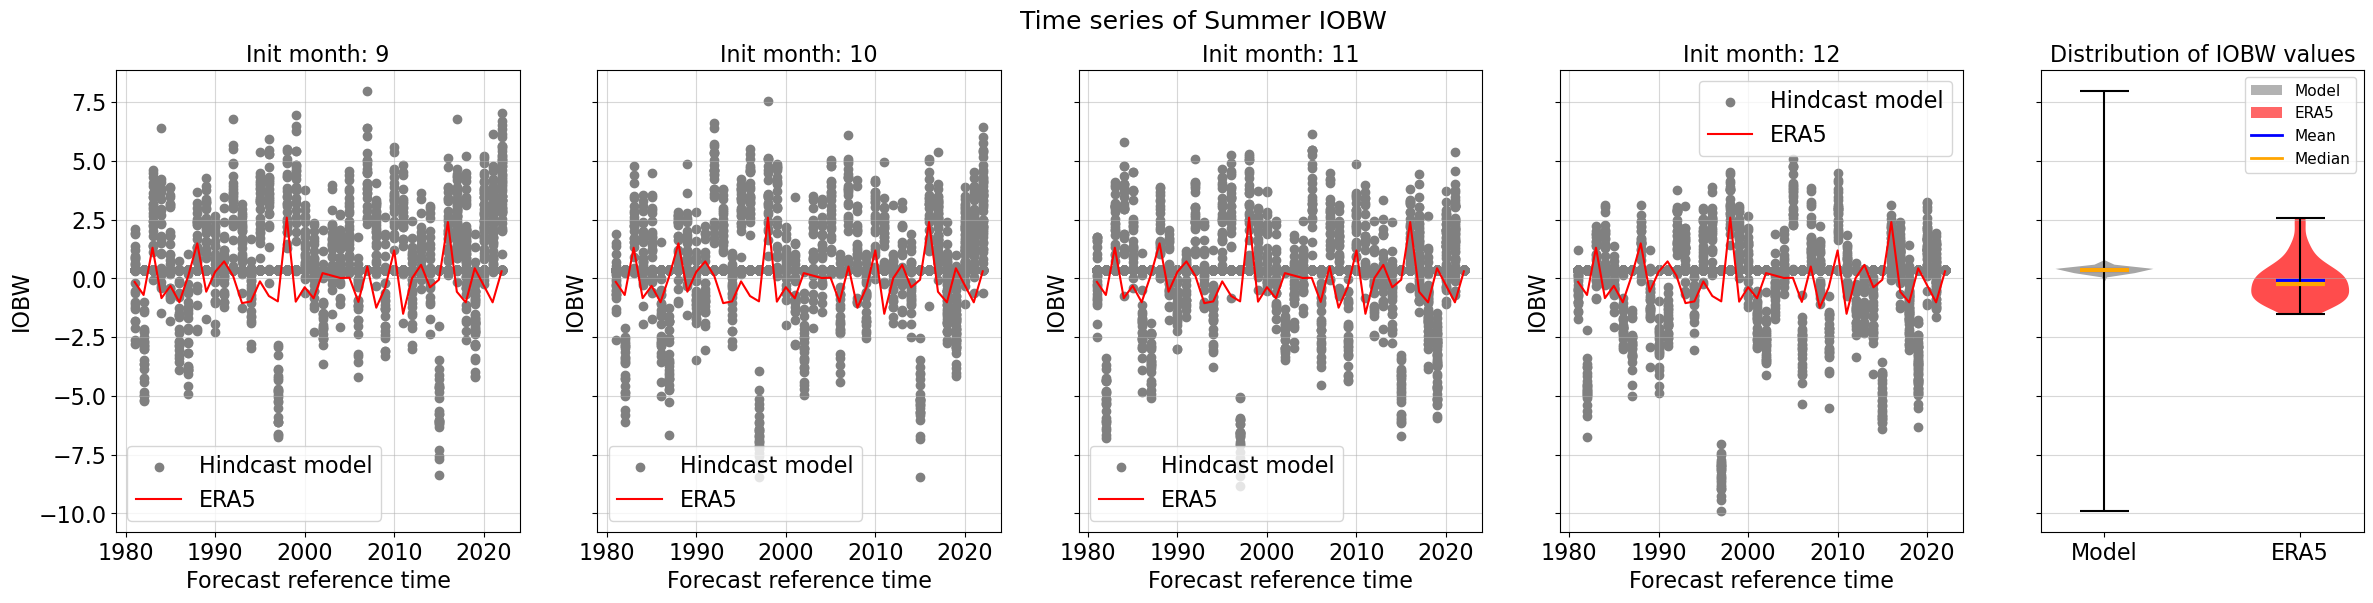

In [28]:
ds_ocean_SON = ds_ocean_SON.set_index(
    sample=["forecast_reference_time", "number", "init_month"]
)

ds_ocean_DJF = ds_ocean_DJF.set_index(
    sample=["forecast_reference_time", "number", "init_month"]
)
folder='Model_eval_plots/'
mapping_oc_SON = {
    list(ds_ocean_SON.data_vars)[1]: "ENSO",
    list(ds_ocean_SON.data_vars)[0]: "IOD"  
}
mapping_oc_DJF = {
    list(ds_ocean_DJF.data_vars)[1]: "ENSO",
    list(ds_ocean_DJF.data_vars)[0]: "IOBW"  
}
for var, era_var in mapping_oc_SON.items():
    a=bootstrap_chain(ds_ocean_SON, 60, var=var)
    boot_perc_oc_SON, era5_perc_oc_SON, fig_oc=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                input_title=f'Model Evaluation Spring {era_var}')
    fig_oc.savefig(folder+f'model_eval_spring_{era_var}.jpg', dpi=300)

    ##timeseries of ENSO & IOD Spring for all init months
    fig_ts_oc_SON=time_series_plot(ds_ocean_SON[var], era_var=era_var, era5_array=era_SON_LaPlata_array,
                                          input_title=f'Time series of Spring {era_var}')
    fig_ts_oc_SON.savefig(folder+f'model_ts_spring_{era_var}.jpg', dpi=300)

for var, era_var in mapping_oc_DJF.items():
    b=bootstrap_chain(ds_ocean_DJF, 60, var=var)
    boot_perc_oc_DJF, era5_perc_oc_DJF, fig_oc_DJF=model_eval_plot(b,
                                                             era_DJF_LaPlata_array[era_var],
                                                             input_title=f'Model evaluation Summer {era_var}')
    fig_oc_DJF.savefig(folder+f'model_eval_summer_{era_var}.jpg', dpi=300)

    ##timeseries of LP Spring t2m and precip for all init months
    fig_ts_oc_DJF=time_series_plot(ds_ocean_DJF[var], era_var=era_var, era5_array=era_DJF_LaPlata_array,
                                          input_title=f'Time series of Summer {era_var}')
    fig_ts_oc_DJF.savefig(folder+f'model_ts_summer_{era_var}.jpg', dpi=300)

In [ ]:
ds_ocean_SON.data_vars
#0 is iod_index/IOB, 1 is nino34

Data variables:
    iod_index  (sample) float64 477kB ...
    nino34     (sample) float64 477kB ...

nino34 ENSO


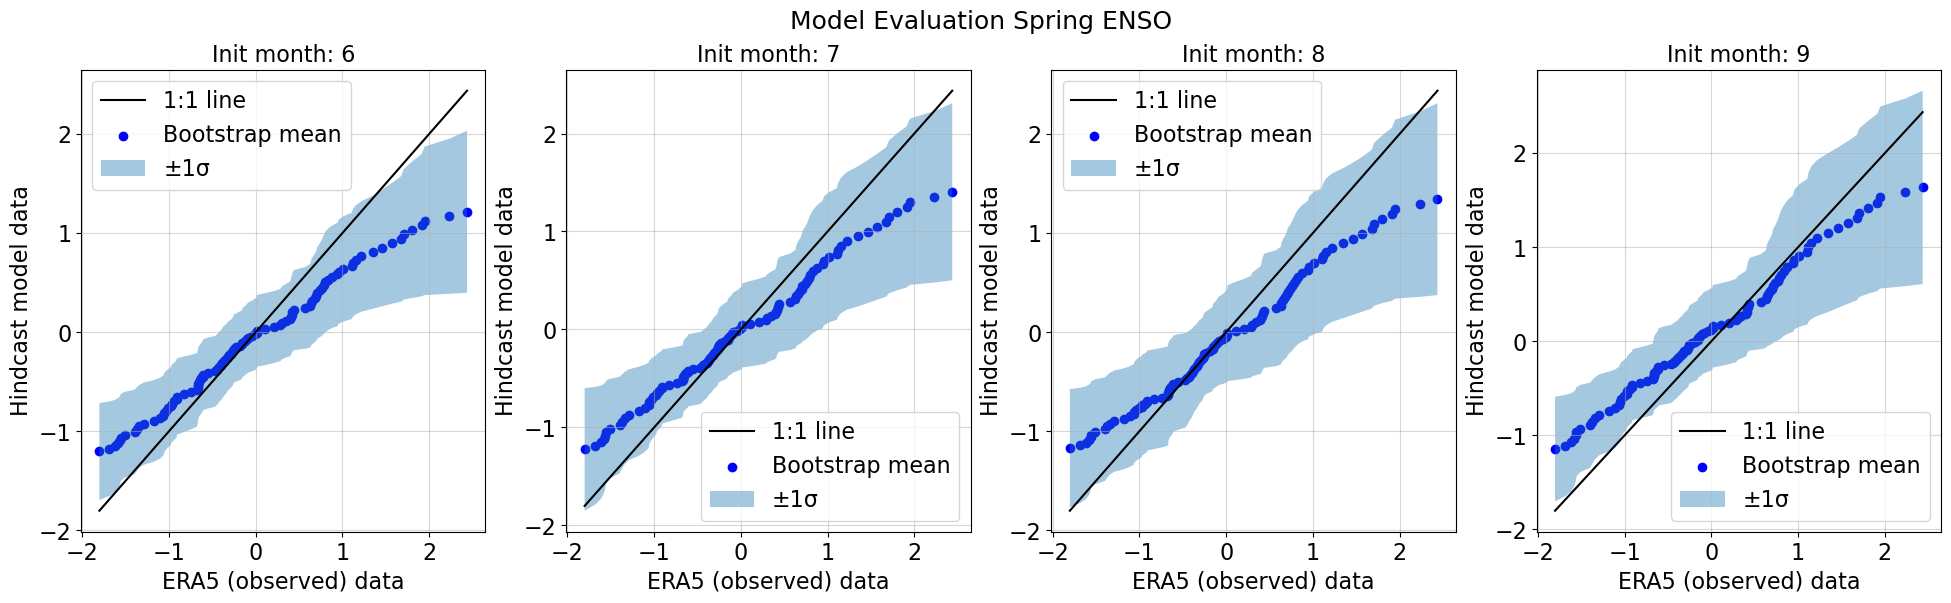

iod_index IOD


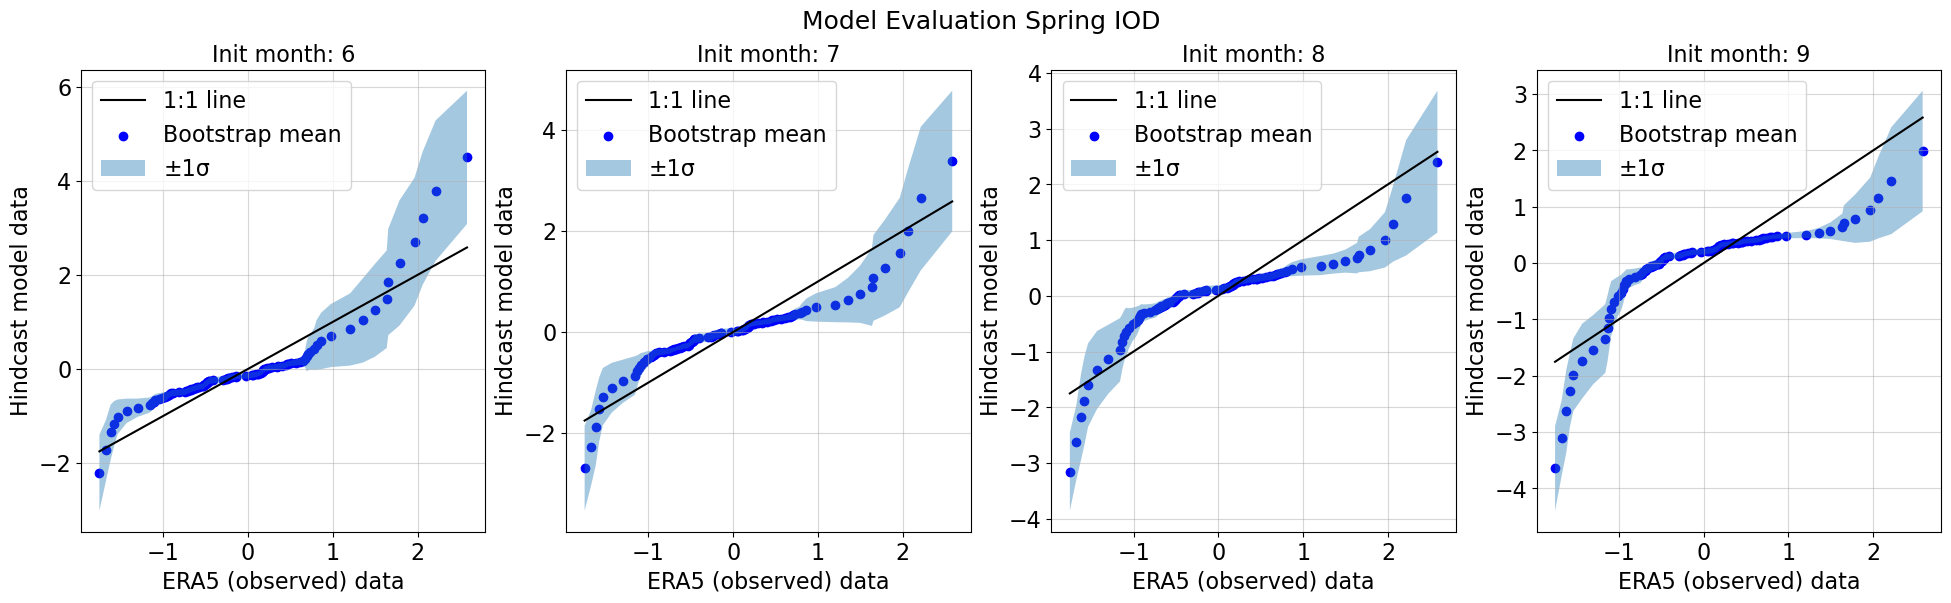

nino34 ENSO


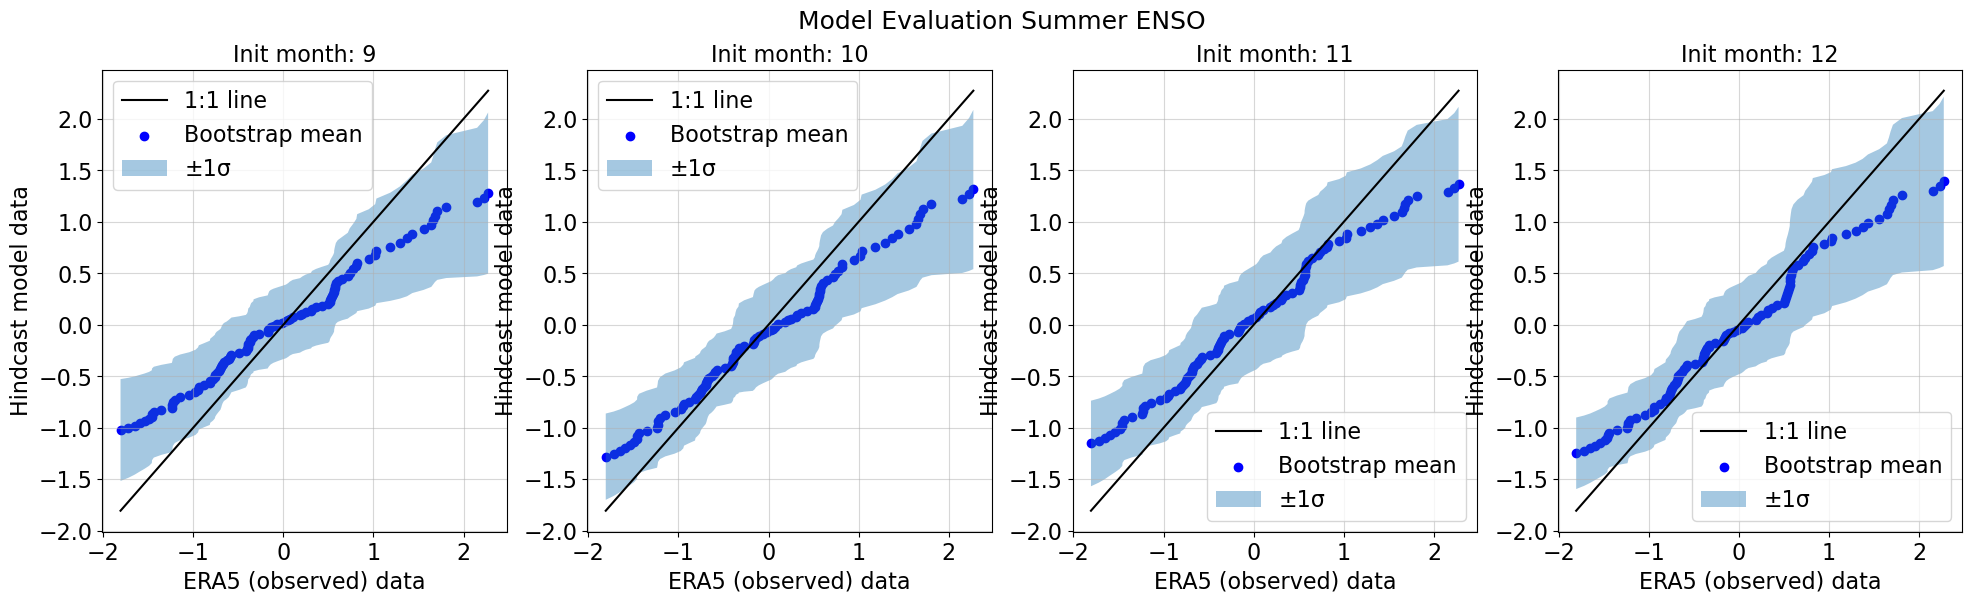

IOBW IOBW


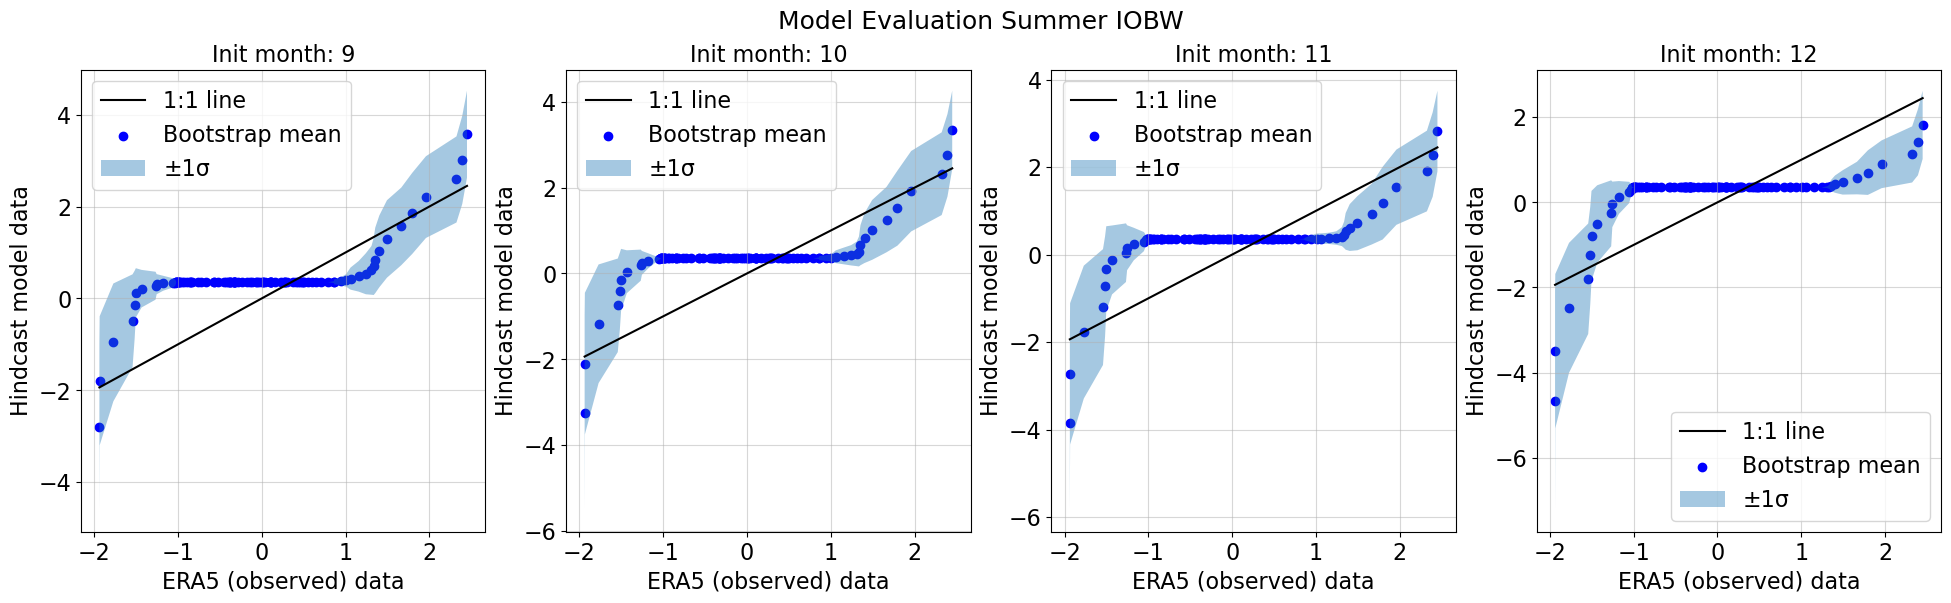

In [34]:
#separate init months
folder='Model_eval_plots/'
mapping = {
    list(ds_ocean_SON.data_vars)[1]: "ENSO",
    list(ds_ocean_SON.data_vars)[0]: "IOD" 
}


months_list_SON=list(np.unique(ds_ocean_SON.init_month.values))
months_list_DJF=list(np.unique(ds_ocean_DJF.init_month.values))

for var, era_var in mapping.items():
    print(var, era_var)
    a=bootstrap_chain(ds_ocean_SON, 60, var=var, sep_lead=True)
    #print(np.shape(a))

    boot_perc_LP_SON, era5_perc_LP_SON, fig_LP=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                            input_title=f'Model Evaluation Spring {era_var}',
                                                            ds_init=ds_ocean_SON[var])
        
    fig_LP.savefig(folder+f'model_eval_spring_{era_var}_all_init.jpg', dpi=300)
        

for var, era_var in mapping_oc_DJF.items():
        print(var, era_var)
        b=bootstrap_chain(ds_ocean_DJF, 60, var=var, sep_lead=True)
        boot_perc_LP_DJF, era5_perc_LP_DJF, fig_LP_DJF=model_eval_plot(b, era5_array=era_DJF_LaPlata_array[era_var],
                                                                        input_title=f'Model Evaluation Summer {era_var}',
                                                                        ds_init=ds_ocean_DJF[var])
        fig_LP_DJF.savefig(folder+f'model_eval_summer_{era_var}_all_init.jpg', dpi=300)
        

Vortex evaluation

In [ ]:
ds_strato_SON = ds_strato_SON.set_index(
    sample=["forecast_reference_time", "number", "init_month"]
)

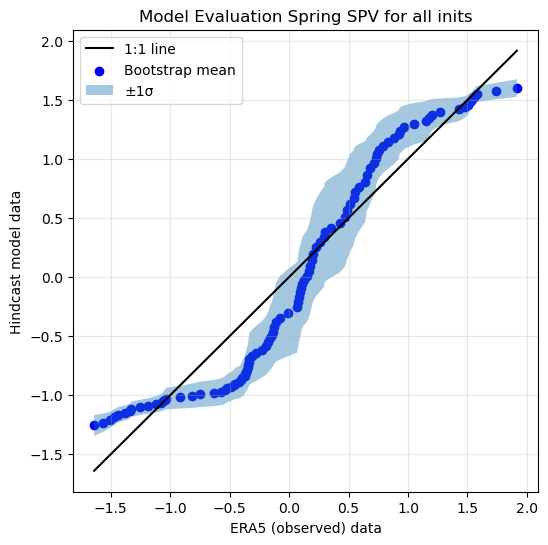

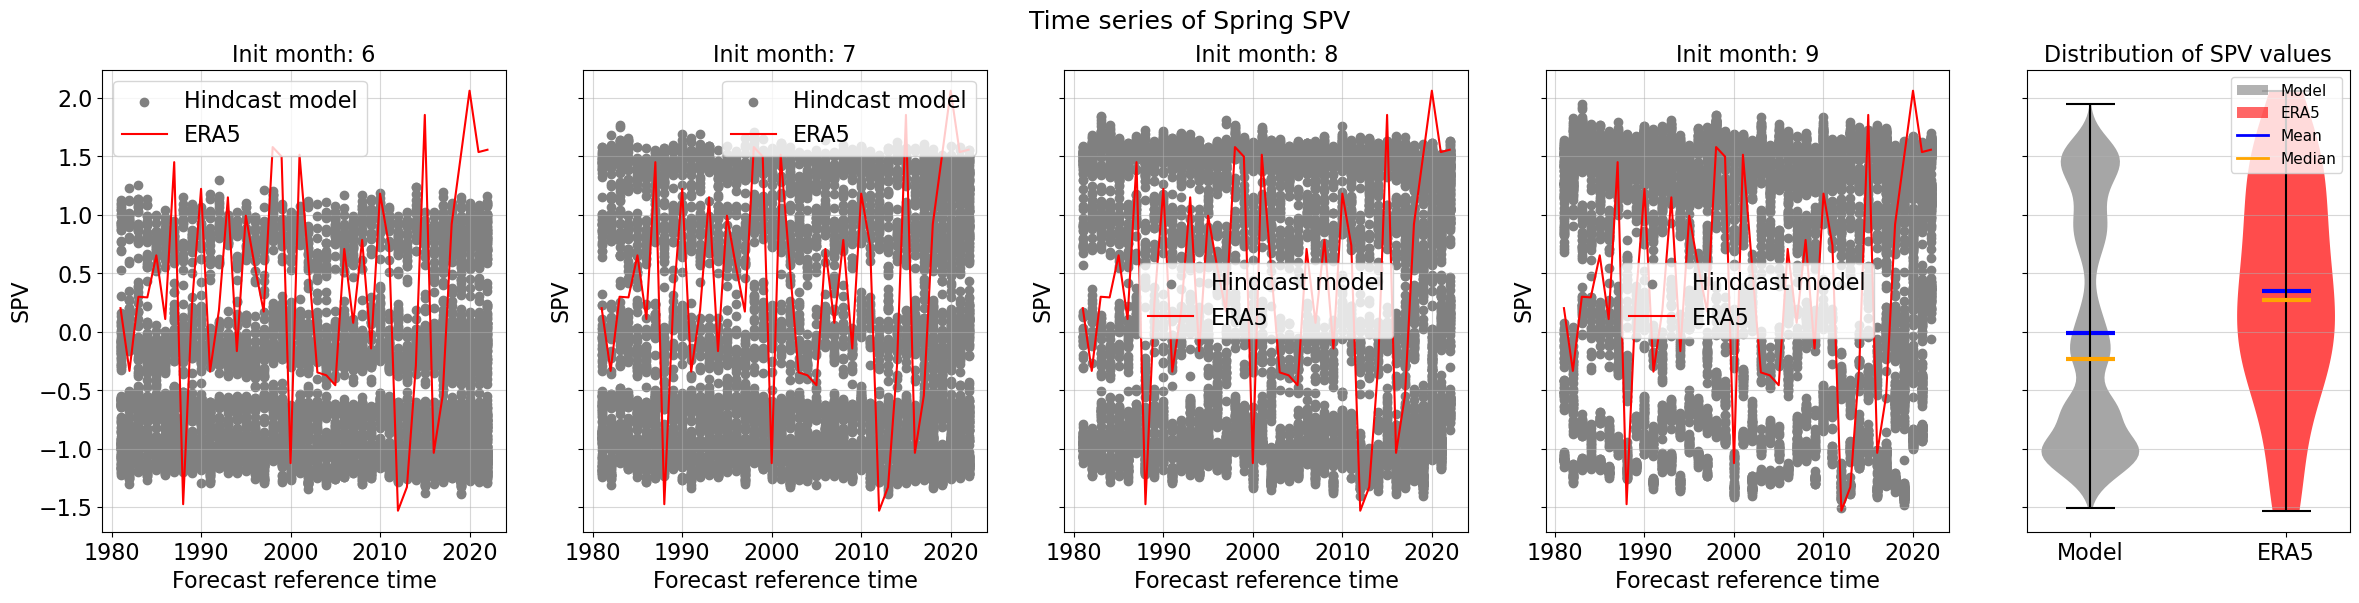

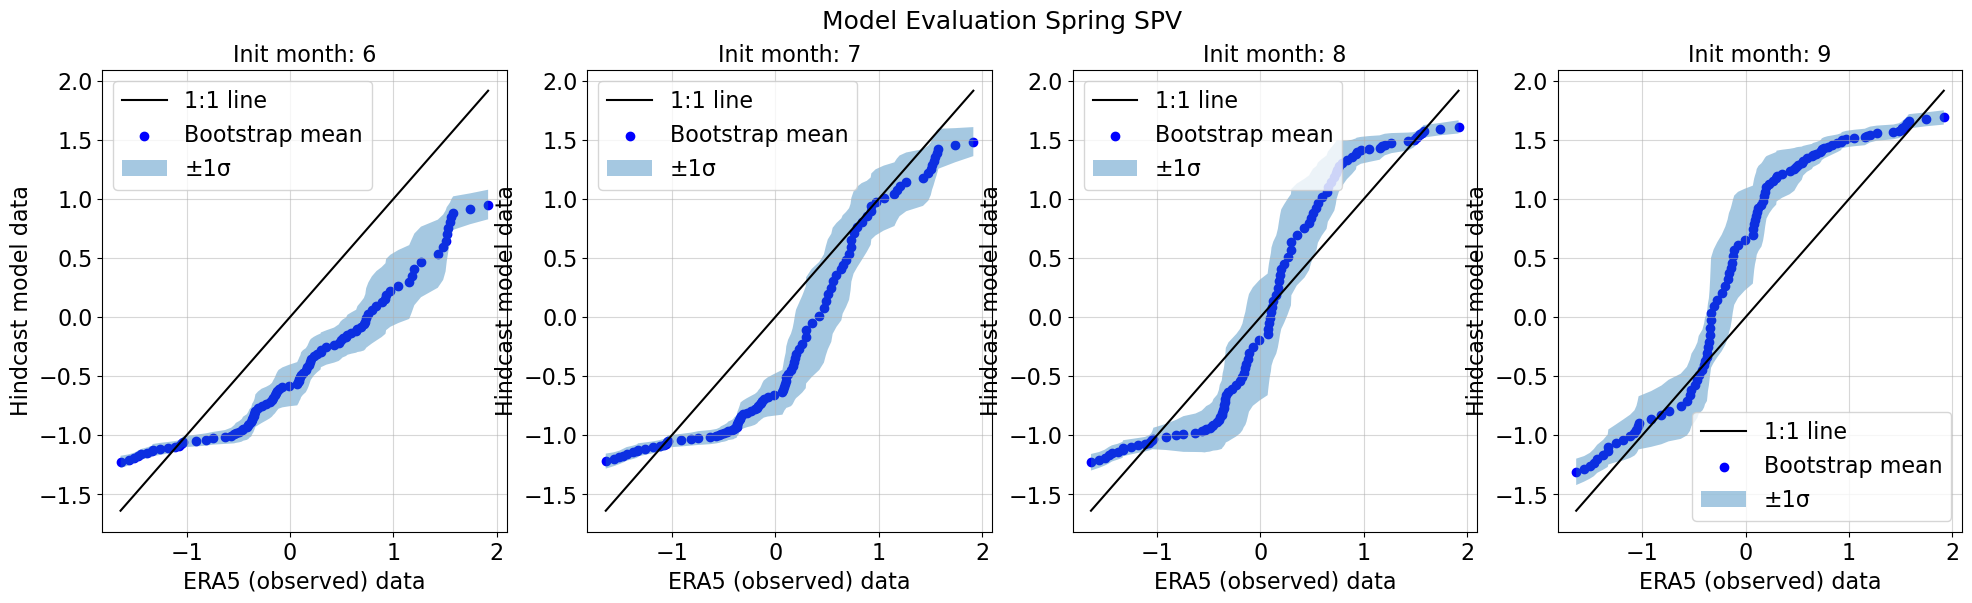

In [ ]:
#separate init months
folder='Model_eval_plots/'
mapping = {
    list(ds_strato_SON.data_vars)[0]: "SPV"}

months_list_SON=list(np.unique(ds_strato_SON.init_month.values))
for var, era_var in mapping.items():
    a=bootstrap_chain(ds_strato_SON, 60, var=var)
    #print(np.shape(a))
    #b=bootstrap_chain(ds_strato_SON, 60, var=var)

    boot_perc_SPV_SON, era5_perc_SPV_SON, fig_whole=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                    input_title=f'Model Evaluation Spring {era_var} for all inits')
    fig_whole.savefig(folder+f'model_eval_spring_{era_var}.jpg', dpi=300)

    fig_ts_SPV_SON=time_series_plot(ds_strato_SON[var], era_var=era_var, era5_array=era_SON_LaPlata_array,
                                          input_title=f'Time series of Spring {era_var}')
    fig_ts_SPV_SON.savefig(folder+f'model_ts_spring_{era_var}.jpg', dpi=300)

    a=bootstrap_chain(ds_strato_SON, 60, var=var, sep_lead=True)
    boot_perc_LP_SON, era5_perc_LP_SON, fig_LP=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                                input_title=f'Model Evaluation Spring {era_var}',
                                                                ds_init=ds_strato_SON[var])
            
    fig_LP.savefig(folder+f'model_eval_spring_{era_var}_all_init.jpg', dpi=300)
    

VB index prep

In [5]:
def detrend_across_time(ds):
    """
    Remove a linear trend across time.

    Important:
    Your dimension is called 'sample', not 'time'.

    Each sample has a coordinate called 'forecast_reference_time'.
    We extract the year from that coordinate and regress each grid point
    against year.

    Because you have 51 ensemble members per year, the same year appears
    many times. That is okay: the trend is fitted across all samples.
    """

    # Extract year from forecast_reference_time
    years = xr.DataArray(
        ds["forecast_reference_time"].dt.year.values,
        dims="sample",
        coords={"sample": ds["sample"]},
        name="year"
    )

    # Center the year to make the regression numerically cleaner
    x = years - years.mean(dim="sample")

    # Output container
    detrended_vars = {}

    for var in ds.data_vars:

        y = ds[var]

        # Mean over sample
        y_mean = y.mean(dim="sample")

        # Linear regression slope:
        # slope = cov(x, y) / var(x)
        slope = ((x * (y - y_mean)).mean(dim="sample")) / ((x ** 2).mean(dim="sample"))

        # Fitted linear trend
        fit = y_mean + slope * x

        # Remove fitted trend
        detrended_vars[var] = y - fit

    out = xr.Dataset(detrended_vars, coords=ds.coords)

    return out


def spatial_average(ds):
    """
    Latitude-weighted spatial average.

    Output:
        one value per sample
    """

    weights = np.cos(np.deg2rad(ds["latitude"]))

    out = ds.weighted(weights).mean(dim=["latitude", "longitude"])

    return out

def standardize(ds):
    """
    Standardize each variable across samples.

    z = value / std

    The mean should already be near zero after anomaly + detrending.
    If you want strict z-score, use:
        (ds - ds.mean("sample")) / ds.std("sample")
    """

    return ds / ds.std(dim="sample")

In [6]:

VB_Aug=pd.read_csv(path+'SEAS5_VortexBreakdown_DOY_Aug.csv')
VB_Sep=pd.read_csv(path+'SEAS5_VortexBreakdown_DOY_Sep.csv')
#display(VB_Sep['forecast_reference_time'])
#display(VB_Aug['forecast_reference_time'])

VB_Aug['init_month']=8
VB_Sep['init_month']=9
#display(era_DJF_Andes_array['VB'])
VB_all=pd.concat([VB_Aug, VB_Sep], axis=0)
VB_all["forecast_reference_time"] = pd.to_datetime(
    VB_all["forecast_reference_time"]
)

#VB_all["year"] = VB_all["forecast_reference_time"].dt.year
#VB_all['year']=VB_all['forecast_reference_time'].str.slice(0,4).astype(int)
display(VB_all)

#set multi index sample
VB_DOY_array = (
    VB_all
    .set_index(["init_month", "number", 'forecast_reference_time'])
    .to_xarray()
)
VB_DOY_array=VB_DOY_array.stack(sample=["init_month", "forecast_reference_time", "number"]).drop_vars(['latitude'])

display(VB_DOY_array)

VB_DOY_era5=xr.open_dataset('../ERA5_dyn_data_ready/VB_DOY_absolute_era5.nc')
VB_DOY_era5=xr.where(VB_DOY_era5['dayofyear']<100, VB_DOY_era5['dayofyear']+365, VB_DOY_era5['dayofyear'])
display(VB_DOY_era5)

,number,forecast_reference_time,latitude,VB_DOY,init_month
0,0,1981-09-01,-60,338.0,8
1,0,1982-09-01,-60,340.0,8
2,0,1983-09-01,-60,342.0,8
3,0,1984-09-01,-60,322.0,8
4,0,1985-09-01,-60,322.0,8
...,...,...,...,...,...
2137,50,2018-09-01,-60,NaN,9
2138,50,2019-09-01,-60,325.0,9
2139,50,2020-09-01,-60,361.0,9
2140,50,2021-09-01,-60,342.0,9


<xarray.Dataset> Size: 171kB
Dimensions:                  (sample: 4284)
Coordinates:
  * sample                   (sample) object 34kB MultiIndex
  * init_month               (sample) int64 34kB 8 8 8 8 8 8 8 ... 9 9 9 9 9 9 9
  * forecast_reference_time  (sample) datetime64[ns] 34kB 1981-09-01 ... 2022...
  * number                   (sample) int64 34kB 0 1 2 3 4 5 ... 46 47 48 49 50
Data variables:
    VB_DOY                   (sample) float64 34kB 338.0 347.0 ... 349.0 341.0

<xarray.DataArray 'dayofyear' (year: 77)> Size: 616B
array([368., 319., 316., 341., 326., 333., 332., 325., 310., 331., 342.,
       327., 344., 319., 336., 314., 336., 326., 325., 315., 337., 333.,
       326., 329., 324., 320., 326., 321., 324., 318., 324., 327., 337.,
       333., 339., 336., 345., 339., 345., 323., 341., 348., 322., 342.,
       340., 328., 352., 350., 336., 356., 367., 331., 359., 337., 332.,
       332., 341., 350., 356., 359., 336., 355., 351., 324., 331., 346.,
       347., 324., 344., 336., 313., 362., 367., 366., 363.,  nan,  nan])
Coordinates:
  * year     (year) int64 616B 1950 1951 1952 1953 1954 ... 2023 2024 2025 2026

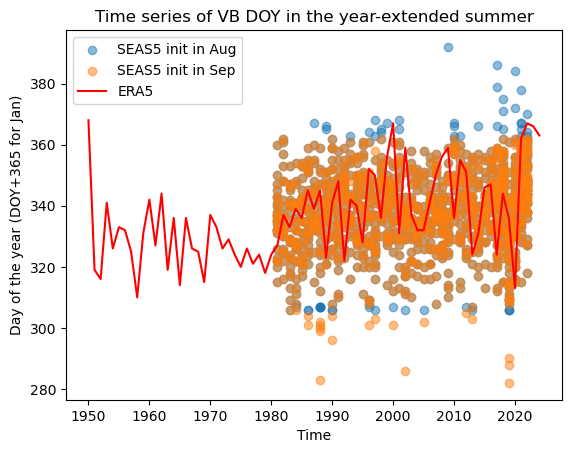

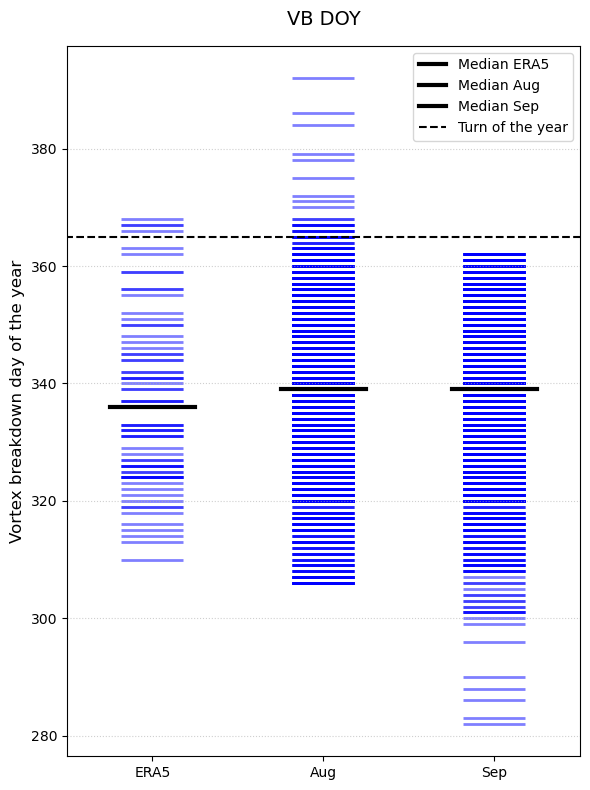

In [8]:
#do plots with absolute values of era5 and model data

#1. time series
plt.scatter(pd.to_datetime(VB_Aug.forecast_reference_time).dt.year, VB_Aug['VB_DOY'], alpha=.5, label='SEAS5 init in Aug')
plt.scatter(pd.to_datetime(VB_Sep.forecast_reference_time).dt.year, VB_Sep['VB_DOY'], alpha=0.5, label='SEAS5 init in Sep')
plt.plot(VB_DOY_era5['year'], VB_DOY_era5, color='red', label='ERA5')
plt.legend()
plt.title('Time series of VB DOY in the year-extended summer')
plt.xlabel('Time')
plt.ylabel('Day of the year (DOY+365 for Jan)')
plt.show()

#2. box plot thingy?

monate_data = [VB_DOY_era5, VB_Aug['VB_DOY'], VB_Sep['VB_DOY']]
monate_namen = ['ERA5', 'Aug', 'Sep']
x_positionen = [1, 2, 3] 

fig, ax = plt.subplots(figsize=(6, 8))


for i, (x_pos, daten) in enumerate(zip(x_positionen, monate_data)):
    
    x_werte = np.full_like(daten, x_pos)
    
    # wide, horizontal stripes, just as in reference plot
    # s= width of stripes, linewidths= thickness of stripes
    ax.scatter(x_werte, daten, marker='_', s=2000, linewidths=2, color='blue', alpha=0.5)
    
    median_y = np.nanmedian(daten)
    ax.plot([x_pos - 0.25, x_pos + 0.25], [median_y, median_y], color='black', linewidth=3, label=f'Median {monate_namen[i]}')
    

ax.set_xticks(x_positionen)
ax.set_xticklabels(monate_namen)
ax.hlines(y=365, xmin=min(x_positionen)-1., xmax=max(x_positionen)+1., linestyle='--', 
          color='black', label='Turn of the year')
ax.set_xlim(0.5, 3.5) 
ax.set_ylabel('Vortex breakdown day of the year', fontsize=12)
ax.grid(axis='y', linestyle=':', alpha=0.6) 

plt.title('VB DOY', fontsize=14, pad=15)
plt.legend()
plt.tight_layout()
plt.show()



<xarray.Dataset> Size: 171kB
Dimensions:                  (sample: 4284)
Coordinates:
  * sample                   (sample) object 34kB MultiIndex
  * init_month               (sample) int64 34kB 8 8 8 8 8 8 8 ... 9 9 9 9 9 9 9
  * forecast_reference_time  (sample) datetime64[ns] 34kB 1981-09-01 ... 2022...
  * number                   (sample) int64 34kB 0 1 2 3 4 5 ... 46 47 48 49 50
Data variables:
    VB_DOY                   (sample) float64 34kB 0.2671 0.9643 ... -0.05015

2142 2142


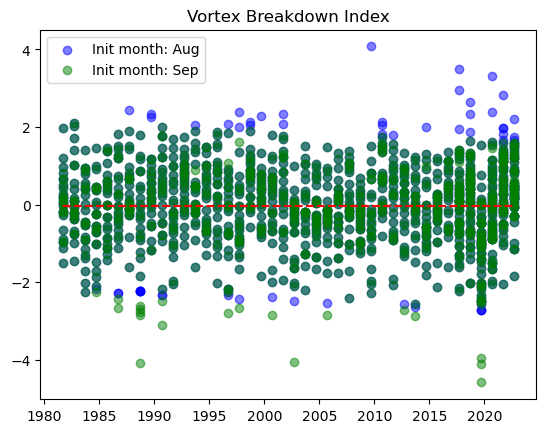

In [15]:
#compute preparation of VB date

#1. detrend
detr_VB= detrend_across_time(VB_DOY_array)
#2. standardize
VB_index=standardize(detr_VB)

VB_index['VB_DOY'].reset_index('sample').to_netcdf(path+'VB_DOY_combined.nc') #, encoding={"zlib": True, "complevel": 4})
display(VB_index)
#print(sum(~np.isnan(VB_index)))
VB_Aug_index=VB_index.sel(init_month=8)['VB_DOY']
VB_Sep_index=VB_index.sel(init_month=9)['VB_DOY']

print(len(VB_Aug_index), len(VB_Aug_index['forecast_reference_time']))
plt.scatter(VB_Aug_index.forecast_reference_time, VB_Aug_index, color='blue', label='Init month: Aug',alpha=.5)
plt.scatter(VB_Sep_index.forecast_reference_time, VB_Sep_index, color='green', label='Init month: Sep', alpha=0.5)
plt.hlines(VB_index['VB_DOY'].mean(), VB_index.forecast_reference_time.min(), VB_index.forecast_reference_time.max(), colors='r', linestyles='dashed')
plt.title('Vortex Breakdown Index')
plt.legend()
plt.show()

/home/glattus/anaconda3/envs/climate/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/tmp/ipykernel_2205535/2043568901.py:86: RuntimeWarning: Mean of empty slice
  boot_mean = np.nanmean(boot_percentiles, axis=1)
/home/glattus/anaconda3/envs/climate/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


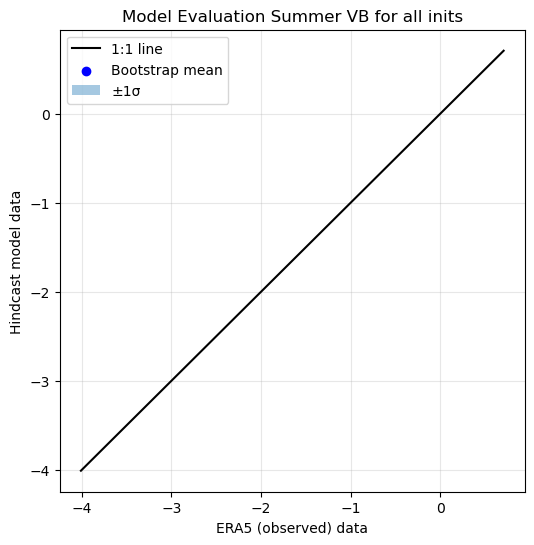

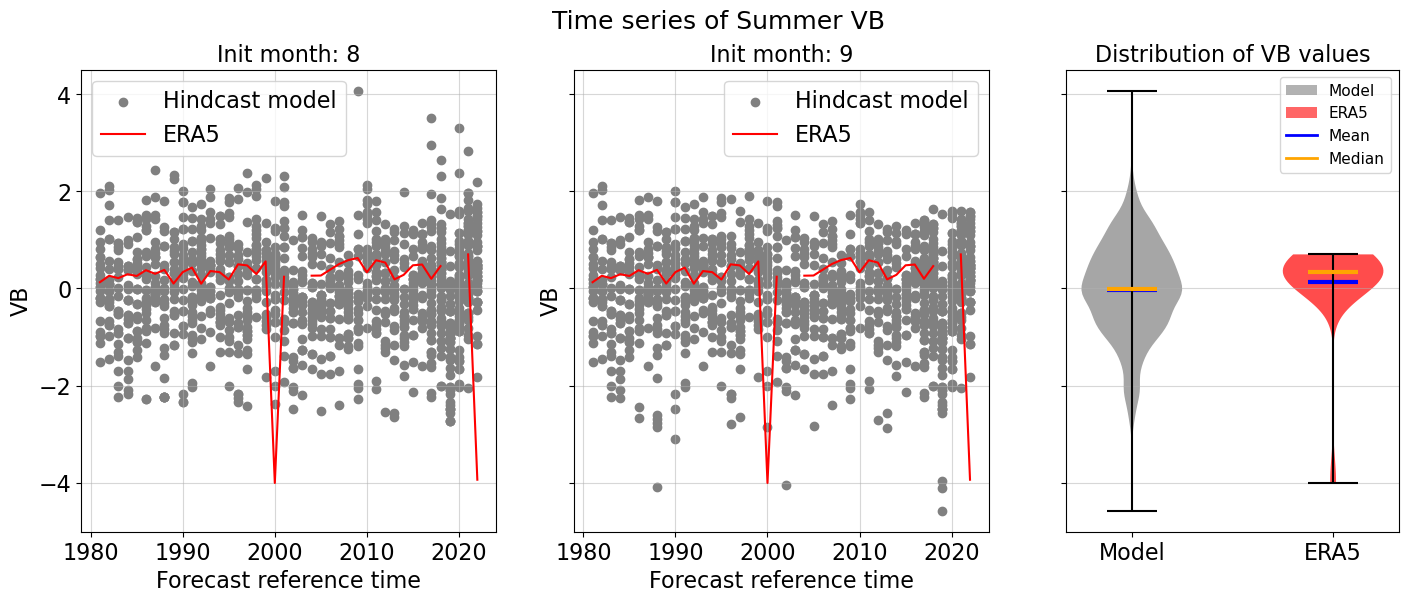

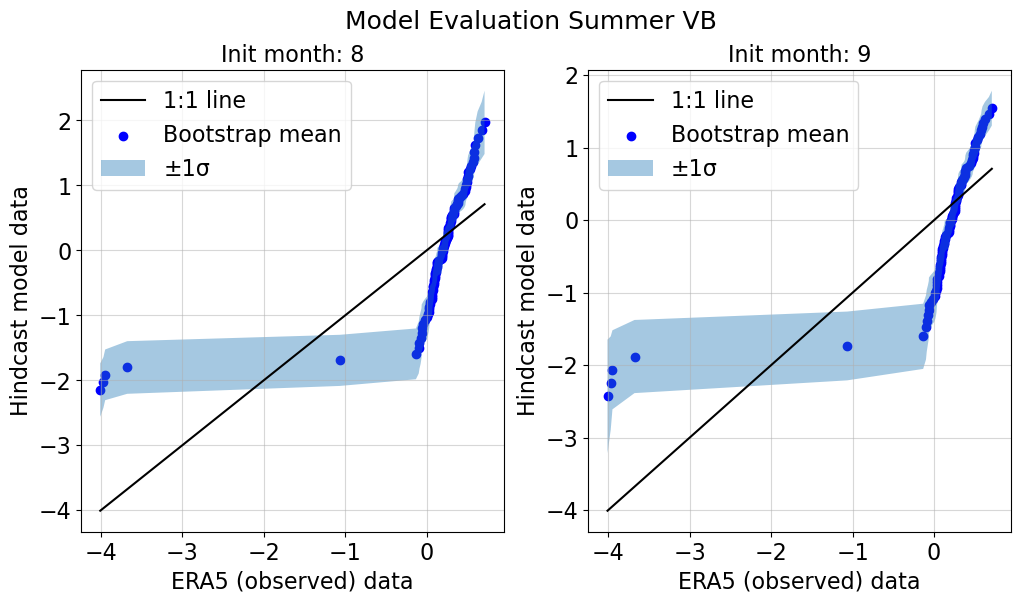

In [16]:
#separate init months
VB_index=drop_duplicates(VB_index)
folder='Model_eval_plots/'
mapping = {
    list(VB_index.data_vars)[0]: "VB"}

months_list_SON=list(np.unique(VB_index.init_month.values))
for var, era_var in mapping.items():
    a=bootstrap_chain(VB_index, 60, var=var)
    #print(np.shape(a))
    #b=bootstrap_chain(ds_strato_SON, 60, var=var)

    boot_perc_VB_SON, era5_perc_VB_SON, fig_whole=model_eval_plot(a, era5_array=era_DJF_LaPlata_array[era_var],
                                                    input_title=f'Model Evaluation Summer {era_var} for all inits')
    fig_whole.savefig(folder+f'model_eval_summer_{era_var}.jpg', dpi=300)

    fig_ts_VB_SON=time_series_plot(VB_index[var], era_var=era_var, era5_array=era_DJF_LaPlata_array,
                                          input_title=f'Time series of Summer {era_var}')
    fig_ts_VB_SON.savefig(folder+f'model_ts_summer_{era_var}.jpg', dpi=300)

    a=bootstrap_chain(VB_index, 60, var=var, sep_lead=True)
    boot_perc_LP_SON, era5_perc_LP_SON, fig_LP=model_eval_plot(a, era5_array=era_DJF_LaPlata_array[era_var],
                                                                input_title=f'Model Evaluation Summer {era_var}',
                                                                ds_init=VB_index[var])
            
    fig_LP.savefig(folder+f'model_eval_summer_{era_var}_all_init.jpg', dpi=300)
    

SAM evaluation

In [ ]:
ds_SAM_SON=xr.open_dataset(path+'SAM_ready_SON.nc')
ds_SAM_DJF=xr.open_dataset(path+'SAM_ready_DJF.nc')

ds_SAM_SON=drop_duplicates(ds_SAM_SON)
ds_SAM_DJF=drop_duplicates(ds_SAM_DJF)

ds_SAM_SON = ds_SAM_SON.set_index(
    sample=["forecast_reference_time", "number", "init_month"]
)

ds_SAM_DJF = ds_SAM_DJF.set_index(
    sample=["forecast_reference_time", "number", "init_month"]
)

display(ds_SAM_SON)

<xarray.Dataset> Size: 3MB
Dimensions:                  (sample: 59568)
Coordinates:
    season                   (sample) <U3 715kB ...
  * sample                   (sample) object 477kB MultiIndex
  * forecast_reference_time  (sample) datetime64[ns] 477kB 1981-06-01 ... 202...
  * number                   (sample) int64 477kB 0 0 0 0 1 1 ... 49 50 50 50 50
  * init_month               (sample) int64 477kB 6 7 8 9 6 7 8 ... 8 9 6 7 8 9
Data variables:
    S_SAM                    (sample) float32 238kB ...
    A_SAM                    (sample) float64 477kB ...

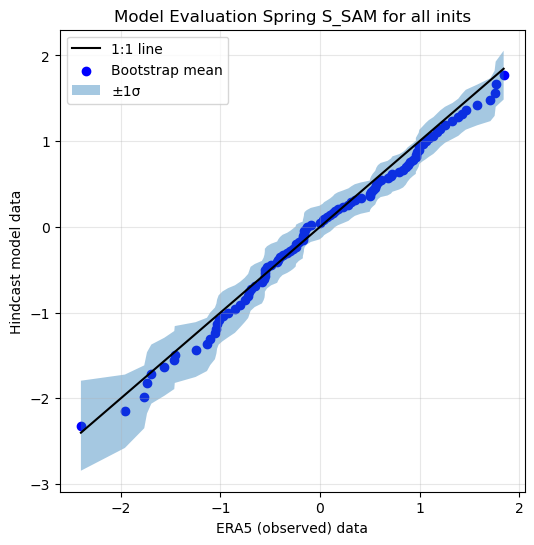

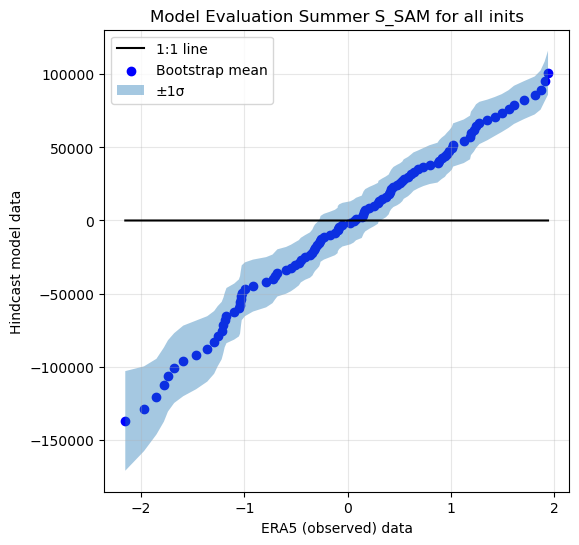

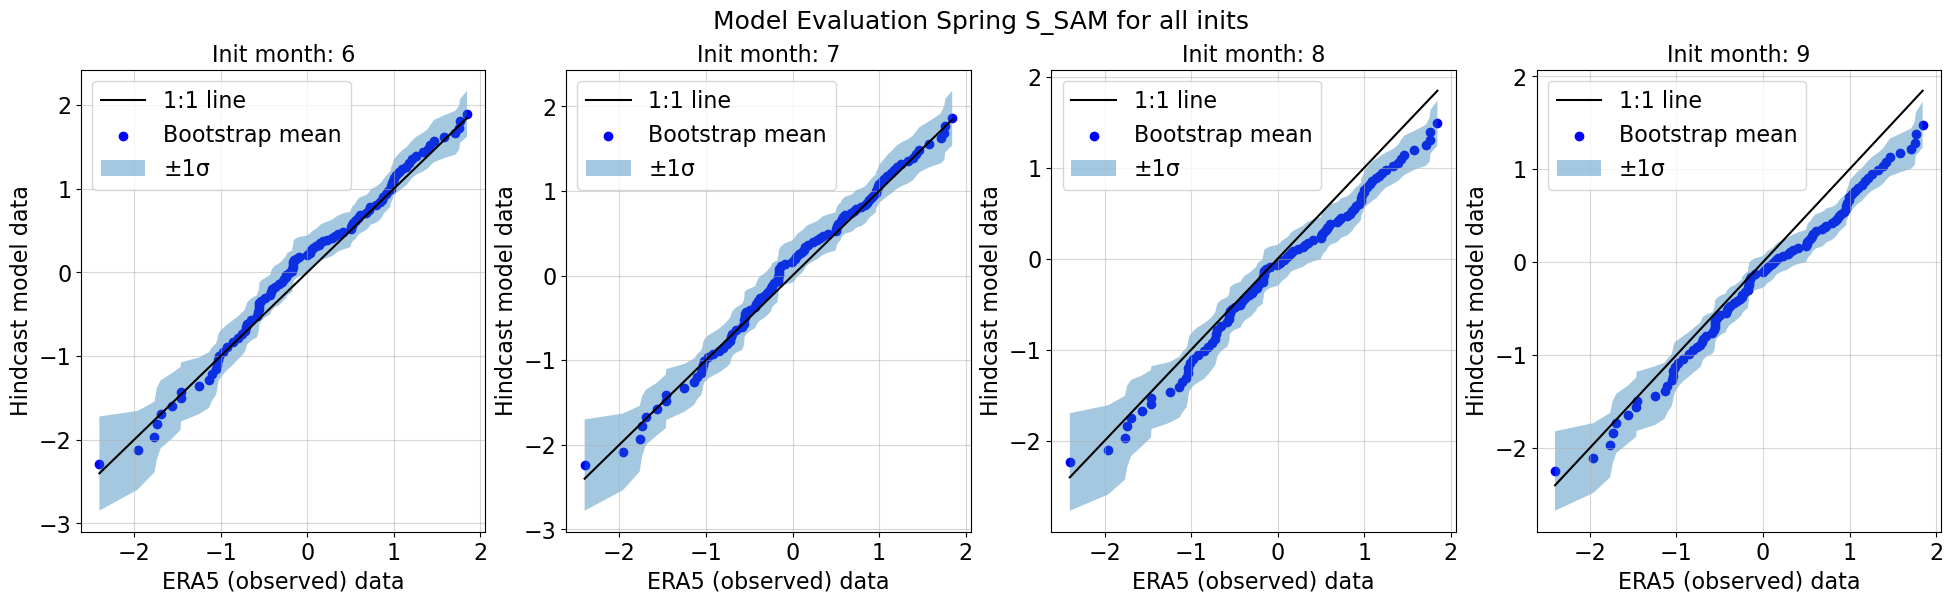

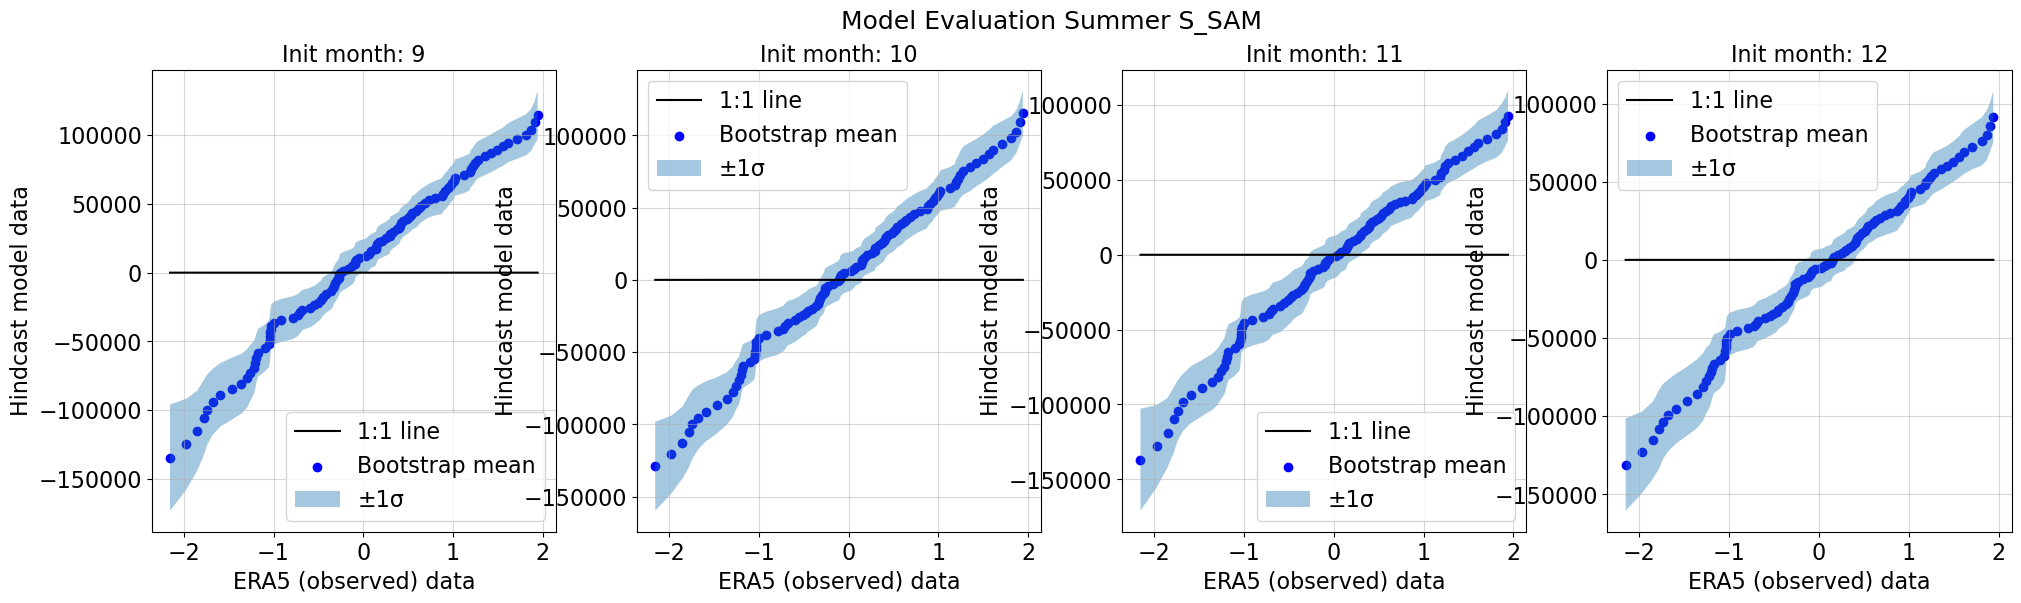

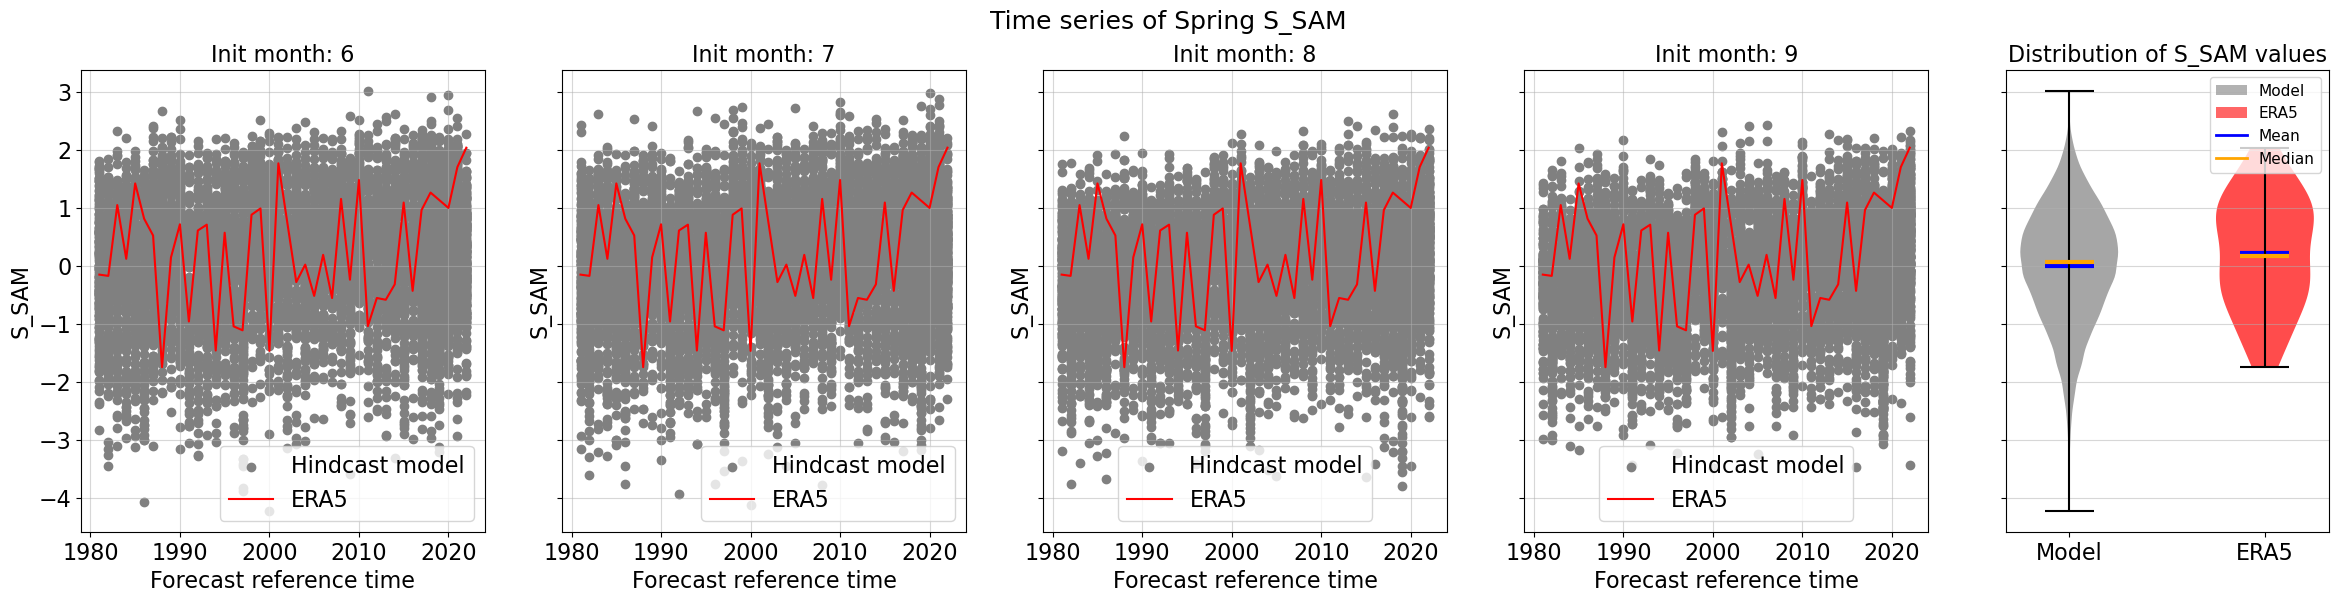

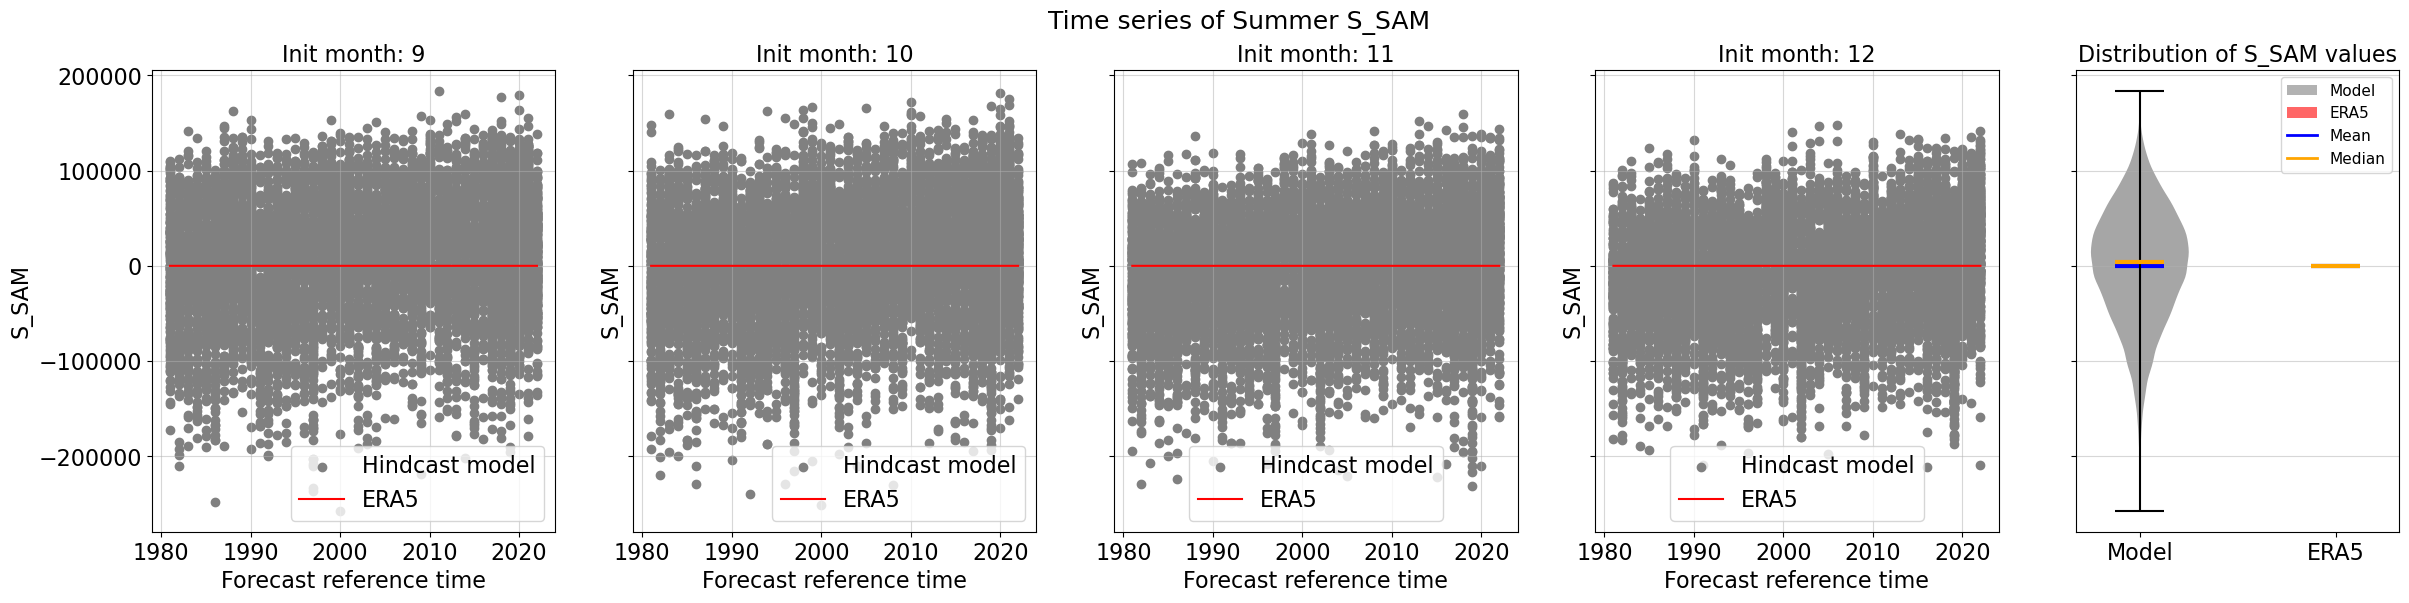

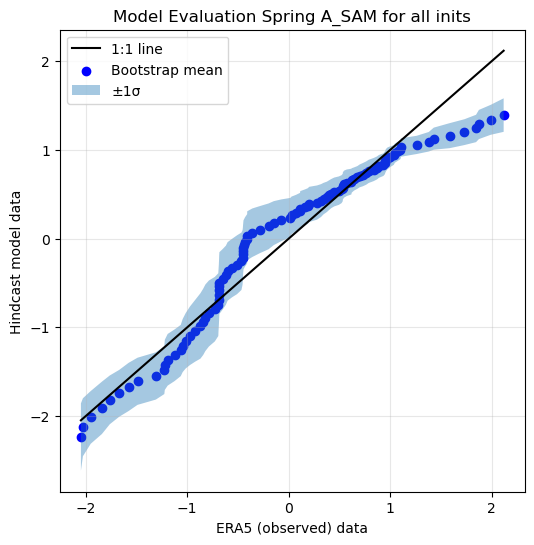

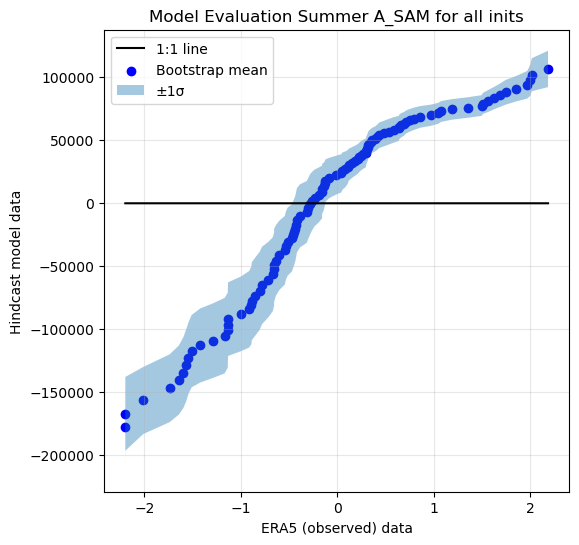

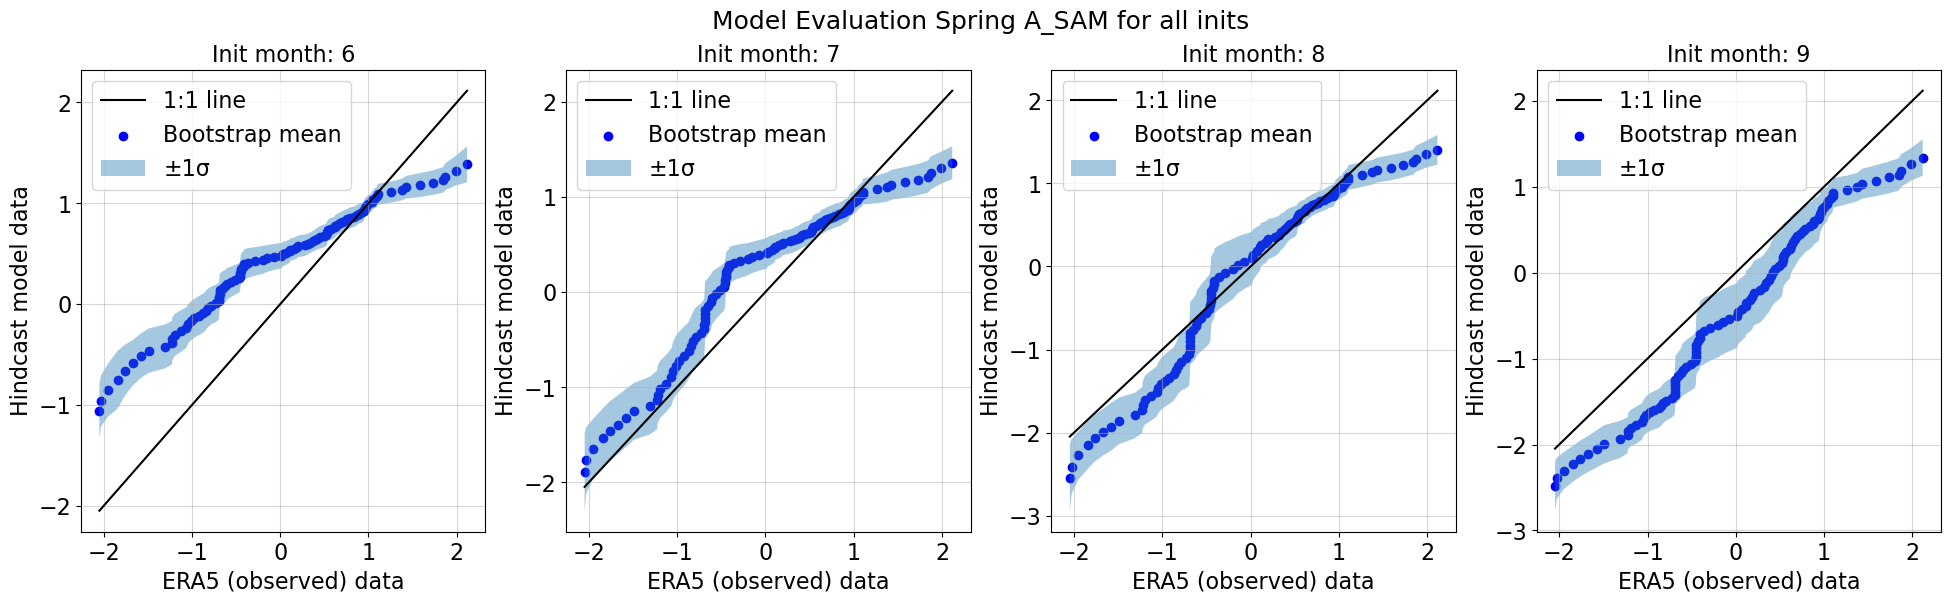

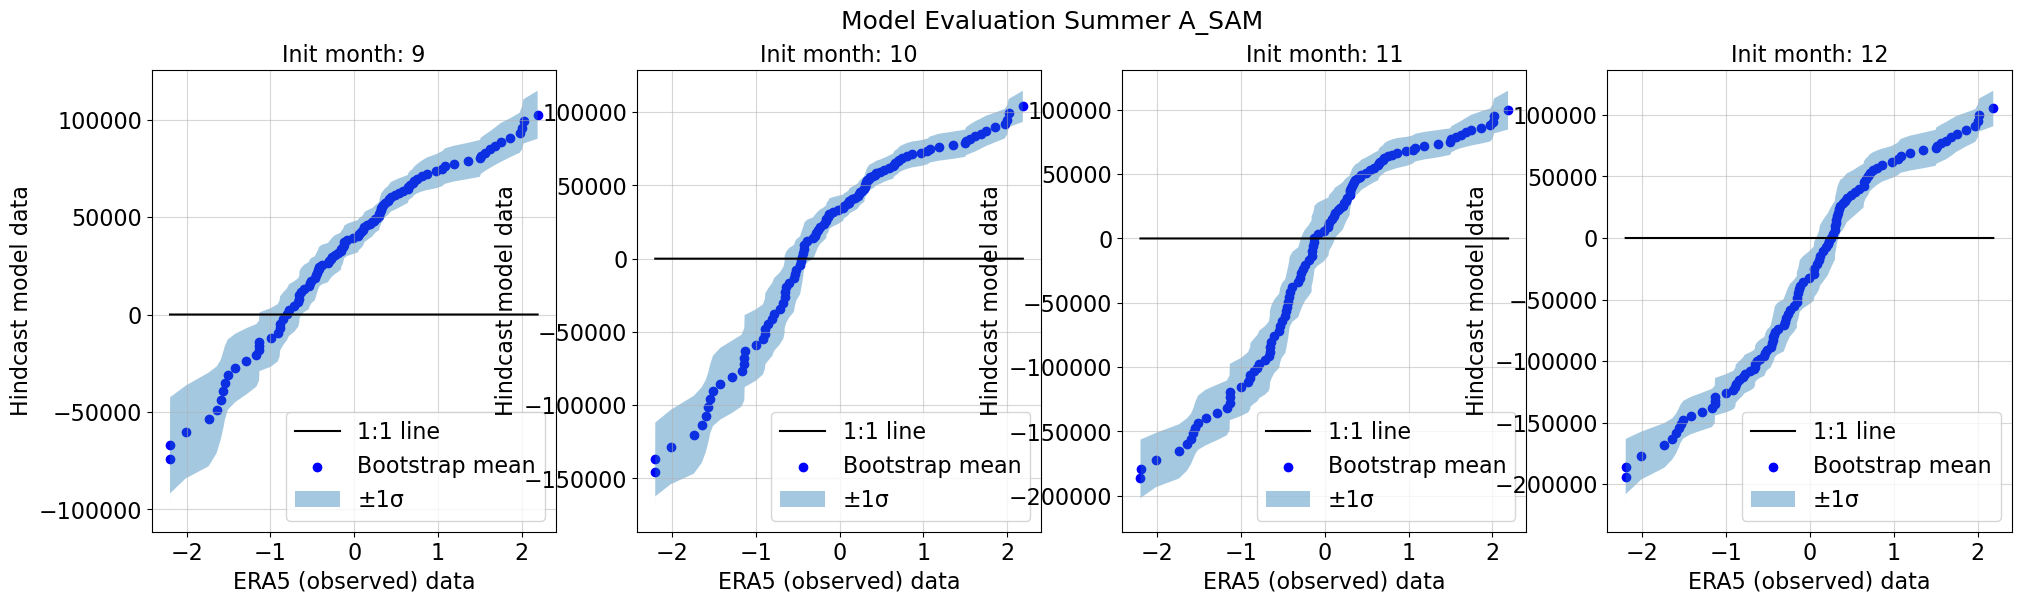

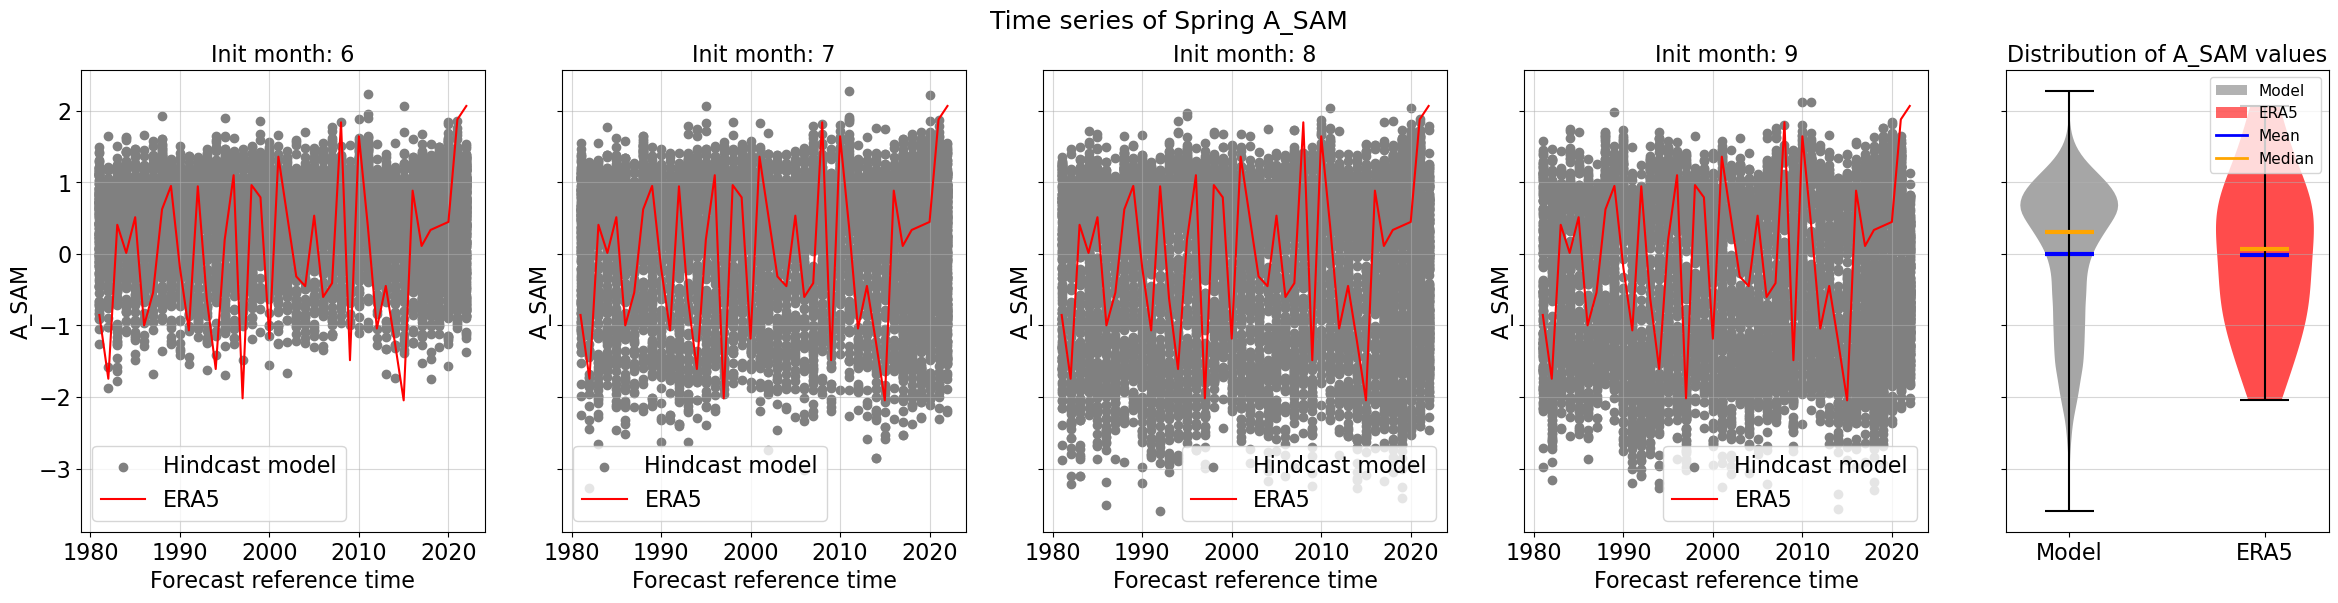

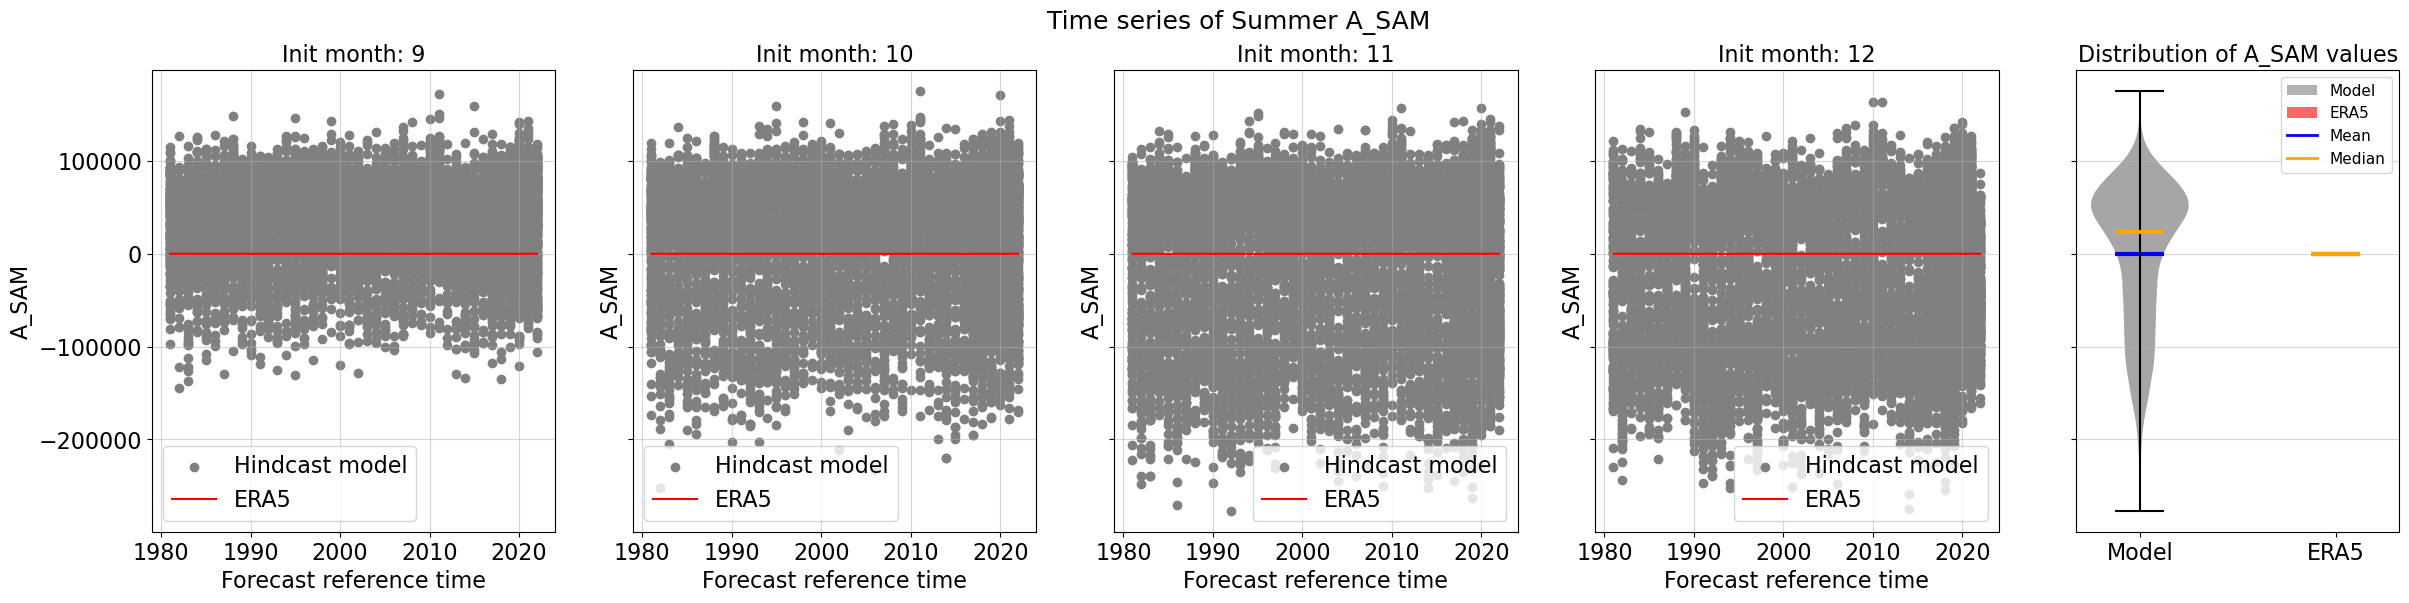

In [ ]:
#separate init months
folder='Model_eval_plots/'
mapping = {
    list(ds_SAM_SON.data_vars)[0]: "S_SAM",
    list(ds_SAM_SON.data_vars)[1]: "A_SAM"}

months_list_SON=list(np.unique(ds_SAM_SON.init_month.values))
for var, era_var in mapping.items():
    #all init together
    a=bootstrap_chain(ds_SAM_SON, 60, var=var)
        #print(np.shape(a))
    b=bootstrap_chain(ds_SAM_DJF, 60, var=var)
    
    boot_perc_SAM_SON, era5_perc_SAM_SON, fig_whole=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                        input_title=f'Model Evaluation Spring {era_var} for all inits')
    fig_whole.savefig(folder+f'model_eval_spring_{era_var}.jpg', dpi=300)
    boot_perc_SAM_DJF, era5_perc_SAM_DJF, fig_whole=model_eval_plot(b, era5_array=era_DJF_LaPlata_array[era_var],
                                                        input_title=f'Model Evaluation Summer {era_var} for all inits')
    fig_whole.savefig(folder+f'model_eval_summer_{era_var}.jpg', dpi=300)

    #separated by init months
    a=bootstrap_chain(ds_SAM_SON, 60, var=var, sep_lead=True)
    #print(np.shape(a))
    #b=bootstrap_chain(ds_strato_SON, 60, var=var)

    boot_perc_SPV_SON, era5_perc_SPV_SON, fig_whole=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                    input_title=f'Model Evaluation Spring {era_var} for all inits',
                                                    ds_init=ds_SAM_SON[var])
    fig_whole.savefig(folder+f'model_eval_spring_{era_var}.jpg', dpi=300)

    a=bootstrap_chain(ds_SAM_DJF, 60, var=var, sep_lead=True)
    boot_perc_LP_SON, era5_perc_LP_SON, fig_LP=model_eval_plot(a, era5_array=era_DJF_LaPlata_array[era_var],
                                                                input_title=f'Model Evaluation Summer {era_var}',
                                                                ds_init=ds_SAM_DJF[var])
            
    fig_LP.savefig(folder+f'model_eval_summer_{era_var}_all_init.jpg', dpi=300)

    #time series
    fig_ts_SAM_SON=time_series_plot(ds_SAM_SON[var], era_var=era_var, era5_array=era_SON_LaPlata_array,
                                              input_title=f'Time series of Spring {era_var}')
    fig_ts_SAM_SON.savefig(folder+f'model_ts_spring_{era_var}.jpg', dpi=300)

    fig_ts_SAM_DJF=time_series_plot(ds_SAM_DJF[var], era_var=era_var, era5_array=era_DJF_LaPlata_array,
                                              input_title=f'Time series of Summer {era_var}')
    fig_ts_SAM_DJF.savefig(folder+f'model_ts_summer_{era_var}.jpg', dpi=300)
    
    